# Step 4: Predict potency and ADMET properties

This notebook reproduces sections 3 onwards of the original pipeline, reading the
generalized outputs of Steps 1-3 directly.

| Step | File consumed |
|---|---|
| Step 1 | `{target}_MLready.csv` — training set, used for overlap removal |
| Step 2 | `{target}_MACAW_embeddings.csv`, `{target}_MACAW_transformer.joblib`, ART models |
| Step 3 | `{Starter}_generated_compounds.csv` per starter (auto-discovered) |

Sections: 3 ART training performance · 4.1 FDA-approved antivirals · 4.2 Reference
drugs · 4.3 DORAnet-generated compounds · 4.4 Starter molecules · 4.5 Experimental
data · 4.6 Final potency-ADMET-ADME scoring plots

### Imports

In [71]:
import os, sys, gc, pickle, warnings, glob

import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')

import shutil
import yaml
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt, matplotlib.lines as mlines
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
from matplotlib.ticker import AutoMinorLocator

import cloudpickle, joblib
from scipy.stats import gaussian_kde

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Descriptors, rdMolDescriptors

from sklearn.model_selection import KFold, GroupKFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed

from admet_ai import ADMETModel
from IPython.display import display

warnings.filterwarnings("ignore")
sys.path.append("../")
import macaw  # noqa: F401
from macaw import MACAW  # noqa: F401
from art.core import RecommendationEngine  # noqa: F401
from art.plot import predictions_vs_observations  # noqa: F401

%run "./../executables/plotting.py"
%config InlineBackend.figure_format = "retina"

matplotlib.rcParams.update({
    "font.family":"serif","font.serif":["Times New Roman"],"mathtext.fontset":"stix",
    "font.size":10,"axes.titlesize":10,"axes.labelsize":10,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,"savefig.dpi":600,
})
tnr = FontProperties(family="serif", style="normal", size=10)

def canonicalizeSmiles(smi):
    if pd.isna(smi): return None
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

## Job configuration

In [4]:
def findProjectRoot(startDir=None, marker="Input_Data"):
    current = os.path.abspath(startDir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(current, marker)): return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError(f"No project root with '{marker}' above {os.getcwd()}")
        current = parent

projectRoot = findProjectRoot()
target      = "Ebola"
dataDir     = os.path.join(projectRoot, "Input_Data")
resultsDir  = os.path.join(projectRoot, target, f"Results_{target}")
os.makedirs(resultsDir, exist_ok=True)

macawTransformerPath = os.path.join(resultsDir, f"{target}_MACAW_transformer.joblib")
macawEmbeddingsFile  = os.path.join(resultsDir, f"{target}_MACAW_embeddings.csv")
mlReadyFile          = os.path.join(resultsDir, f"{target}_MLready.csv")

artModelPaths = {
    "MACAW":     os.path.join(resultsDir,"Step2B_BuildModel_wART","ART_MACAW","ART_results","art.cpkl"),
    "MoLFormer": os.path.join(resultsDir,"Step2B_BuildModel_wART","ART_MolFormer","ART_results","art.cpkl"),
    "MIST":      os.path.join(resultsDir,"Step2B_BuildModel_wART","ART_MIST","ART_results","art.cpkl"),
    "ChemBERTa": os.path.join(resultsDir,"Step2B_BuildModel_wART","ART_ChemBERTa_wPCA","ART_results","art.cpkl"),
}

drugBankDir          = os.path.join(dataDir, "Toxicity", "DrugBank")
drugBankFDAFile      = os.path.join(projectRoot, "Input_Data", "drugBankDrug_FDAapproved_antiviral_wToxicity.csv")
drugBankWithdrawnFile = os.path.join(projectRoot, "Input_Data", "drugBankDrugWithdrawnDataDF_wADMET.csv")

ReferenceDrugs = {
    "Remdesivir":    "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Molnupiravir":  r"CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O",
    "Favipiravir":   "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

StarterMoleculesDict = {
    "Inosine":    "C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O",
    "Adenosine":  "C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N",
    "Guanosine":  "C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N=C(NC2=O)N",
    "Xanthosine": "C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)NC(=O)NC2=O",
}

ExperimentalPotencyDict = {
    "Remdesivir":    {"smiles":"CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
                     "pPotencyValues":[7.07,6.85,6.89,7.22,7.15,7.18,7.68,7.85,8.52,7.11,6.87,7.15]},
    "Favipiravir":   {"smiles":"C1=C(N=C(C(=O)N1)C(=O)N)F","pPotencyValues":[4.17,3.96]},
    "Brincidofovir": {"smiles":"CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O","pPotencyValues":[6.10,6.18,6.06]},
}

baseColorMap = {
    "Inosine":"#984EA3","Adenosine":"#377EB8","Guanosine":"#4DAF4A","Xanthosine":"#E41A1C",
    "Remdesivir":"#FF7F00","Favipiravir":"#A65628","Brincidofovir":"#F781BF","Molnupiravir":"#17BECF",
}

coreToxicityCols  = ["AMES","hERG","DILI","ClinTox","Carcinogens_Lagunin","Skin_Reaction","LD50_Zhu"]
mechanisticAlertCols = ["SR-ARE","SR-ATAD5","SR-HSE","SR-MMP","SR-p53","NR-AR-LBD","NR-AR",
                        "NR-AhR","NR-Aromatase","NR-ER-LBD","NR-ER","NR-PPAR-gamma"]
admeLiabilityCols = ["BBB_Martins","Pgp_Broccatelli","Caco2_Wang","HIA_Hou","PAMPA_NCATS",
                     "Bioavailability_Ma","CYP1A2_Veith","CYP2C19_Veith",
                     "CYP2C9_Substrate_CarbonMangels","CYP2C9_Veith",
                     "CYP2D6_Substrate_CarbonMangels","CYP2D6_Veith",
                     "CYP3A4_Substrate_CarbonMangels","CYP3A4_Veith"]
potencyCols = ["pPotency_prediction","pPotency_std","pPotency_lower_95CI","pPotency_upper_95CI",
               "IC50(M)_prediction","IC50(M)_lower_95CI","IC50(M)_upper_95CI"]
topN      = 20
paramGrid = {"C":[10],"epsilon":[0.1],"gamma":["scale"],"kernel":["rbf"]}
nSplits   = 10

print("Target:", target, "| resultsDir:", resultsDir)
for lbl, p in [("MACAW embeddings",macawEmbeddingsFile),
               ("MACAW transformer",macawTransformerPath),
               ("MLready",mlReadyFile),
               ("ART MACAW",artModelPaths["MACAW"]),
               ("DrugBank FDA",drugBankFDAFile)]:
    print(f"  {lbl}: {'found' if os.path.exists(p) else 'MISSING'} -> {os.path.basename(p)}")

Target: Ebola | resultsDir: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola
  MACAW embeddings: found -> Ebola_MACAW_embeddings.csv
  MACAW transformer: found -> Ebola_MACAW_transformer.joblib
  MLready: found -> Ebola_MLready.csv
  ART MACAW: found -> art.cpkl
  DrugBank FDA: found -> drugBankDrug_FDAapproved_antiviral_wToxicity.csv


### Helper functions

In [5]:
def loadTransformer(path):
    try: return joblib.load(path)
    except Exception:
        with open(path,"rb") as h: return pickle.load(h)

def macawEmbed(df, smilesCol, transformer):
    emb  = transformer.transform(df[smilesCol])
    cols = [f"MACAW_{i+1}" for i in range(emb.shape[1])]
    return pd.concat([df, pd.DataFrame(emb, columns=cols, index=df.index)], axis=1)

def artPredict(dfWMacaw, art, idCols):
    macawCols     = [c for c in dfWMacaw.columns if c.startswith("MACAW_")]
    mean, std     = art.post_pred_stats(dfWMacaw[macawCols].values)
    out           = dfWMacaw[[c for c in idCols if c in dfWMacaw.columns]].copy()
    out["pPotency_prediction"]  = mean
    out["pPotency_std"]         = std
    out["pPotency_lower_95CI"]  = mean - 1.96*std
    out["pPotency_upper_95CI"]  = mean + 1.96*std
    out["IC50(M)_prediction"]   = 10**(-mean)
    out["IC50(M)_lower_95CI"]   = 10**(-out["pPotency_upper_95CI"])
    out["IC50(M)_upper_95CI"]   = 10**(-out["pPotency_lower_95CI"])
    return out.sort_values("pPotency_prediction",ascending=False).reset_index(drop=True)

def computeAdmet(df, smilesCol):
    smilesList = df[smilesCol].dropna().astype(str).tolist()
    pred = ADMETModel().predict(smiles=smilesList)
    pred = pred if isinstance(pred,pd.DataFrame) else pd.DataFrame(pred)
    if "Canonical_SMILES" not in pred.columns:
        pred = pred.reset_index().rename(columns={"index":"Canonical_SMILES"})
    return df.merge(pred, on=smilesCol, how="left")

def retainEndpoints(df, idCols, withPotency=True):
    keep  = [c for c in idCols if c in df.columns]
    if withPotency: keep += [c for c in potencyCols if c in df.columns]
    keep += [c for c in coreToxicityCols+mechanisticAlertCols+admeLiabilityCols if c in df.columns]
    return df[keep].copy()

def removeOverlap(df, smilesCol, trainSet, label=""):
    before  = len(df)
    overlap = set(df[smilesCol].dropna().astype(str)) & trainSet
    out     = df[~df[smilesCol].isin(trainSet)].reset_index(drop=True)
    print(f"{label} overlap removed: {len(overlap):,} | remaining: {len(out):,}")
    return out

def showRange(df, label=""):
    vMin = df.loc[df["pPotency_prediction"].idxmin()]
    vMax = df.loc[df["pPotency_prediction"].idxmax()]
    print(f"{label} pPotency {vMin['pPotency_prediction']:.2f}±{vMin['pPotency_std']:.2f} – "
          f"{vMax['pPotency_prediction']:.2f}±{vMax['pPotency_std']:.2f}")

## 3. ART training performance

In [6]:
trainingData_wMACAW = pd.read_csv(macawEmbeddingsFile)
trainingData        = pd.read_csv(mlReadyFile)
macawInputCols      = [c for c in trainingData_wMACAW.columns if c.startswith("MACAW_")]
trainingSmilesSet   = set(trainingData["Canonical_SMILES"].dropna().astype(str))
macawTransformer    = loadTransformer(macawTransformerPath)
print(f"MACAW embeddings: {len(macawInputCols)}")
print(f"Training rows (with duplicates): {len(trainingData):,} | Unique SMILES: {len(trainingSmilesSet):,}")

MACAW embeddings: 60
Training rows (with duplicates): 2,704 | Unique SMILES: 665


ART MACAW loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step2B_BuildModel_wART/ART_MACAW/ART_results/art.cpkl


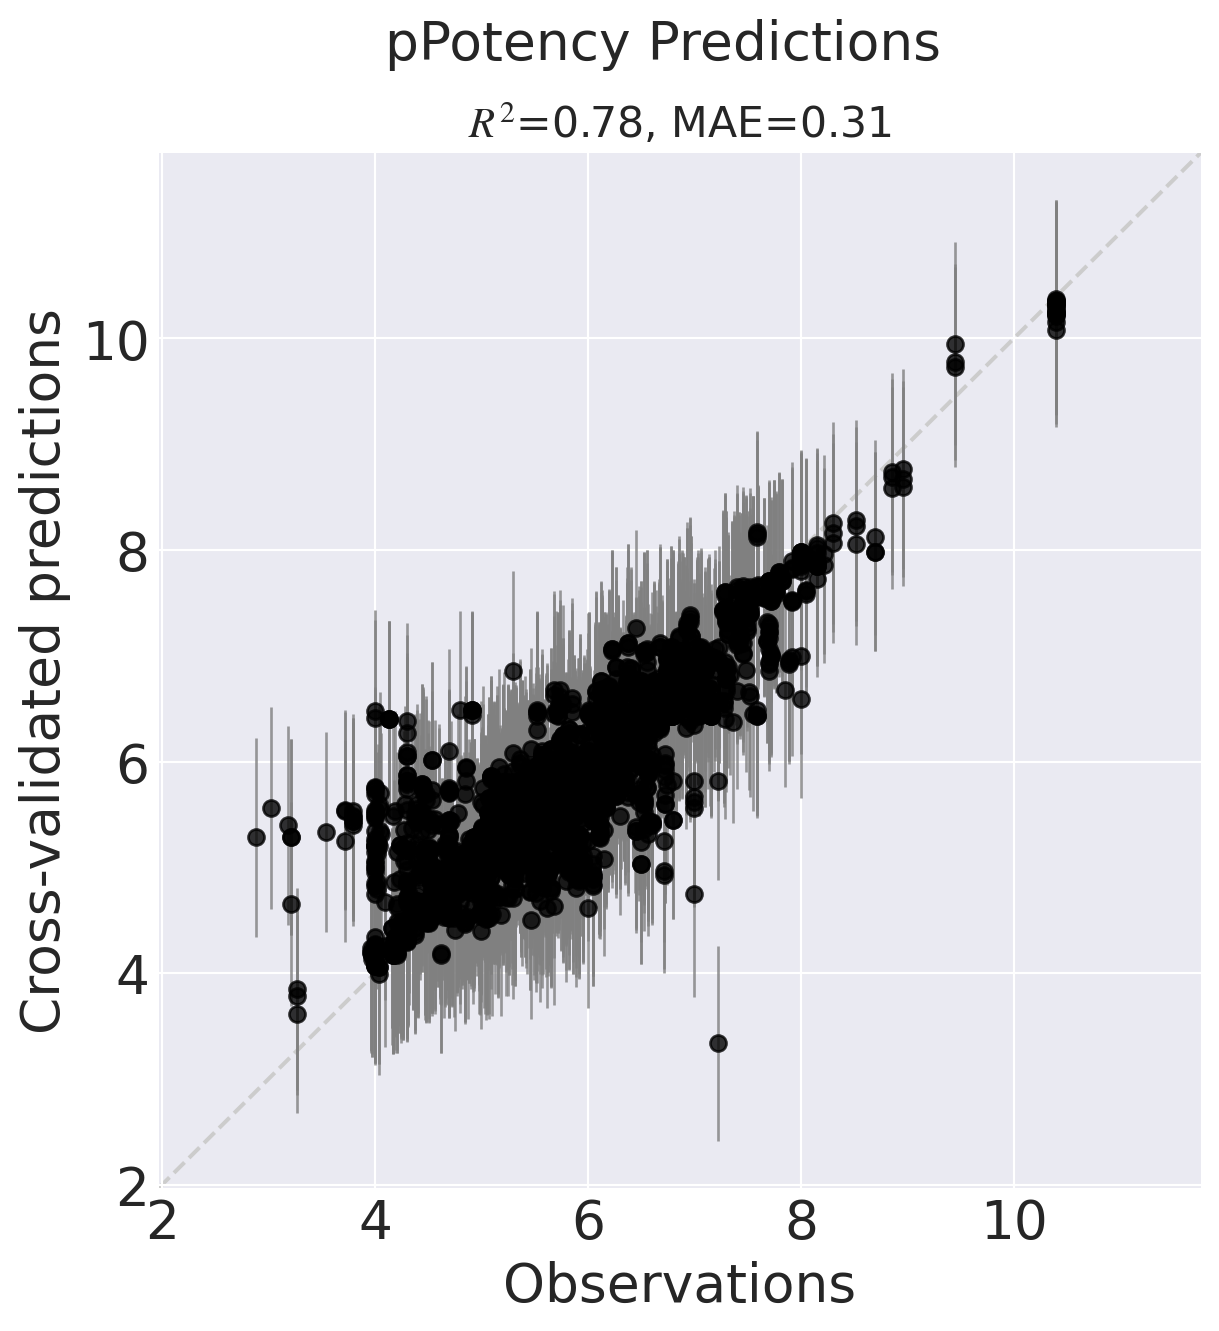

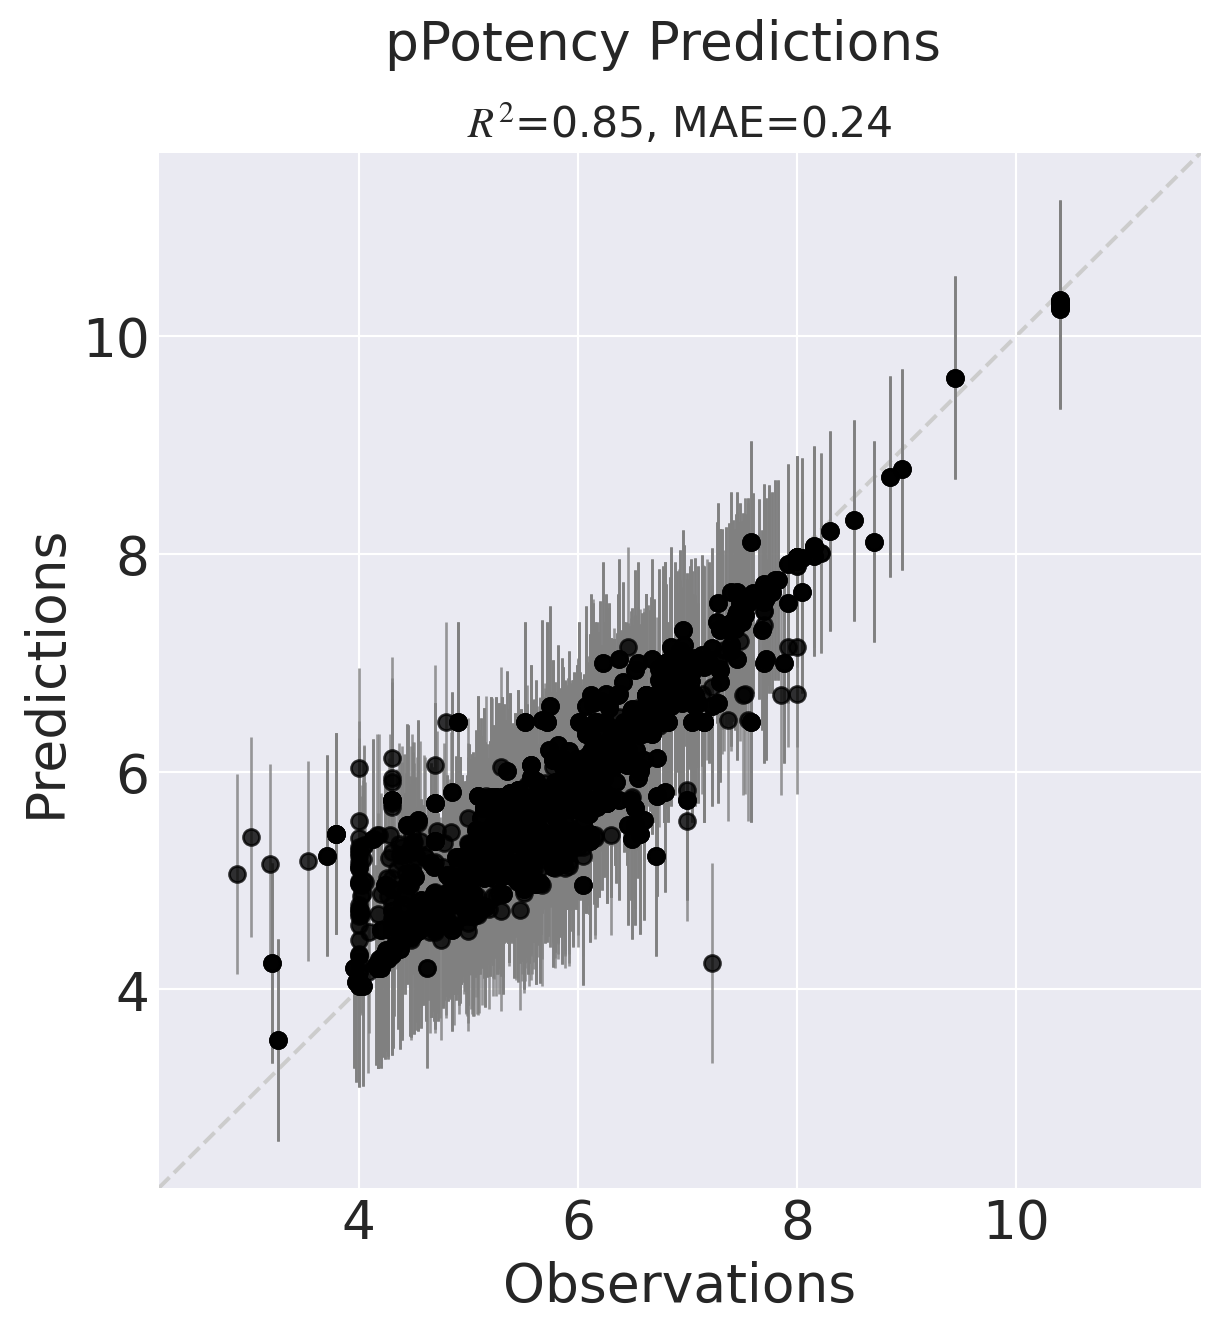

In [7]:
with open(artModelPaths["MACAW"],"rb") as h: art_macaw = cloudpickle.load(h)
art_macaw.output_dir = resultsDir; os.makedirs(resultsDir, exist_ok=True)
print(f"ART MACAW loaded from: {artModelPaths['MACAW']}")
predictions_vs_observations(art_macaw, cv=True,  error_bars=True)
predictions_vs_observations(art_macaw, cv=False, error_bars=True)

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_MACAW_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_MACAW_CV.png


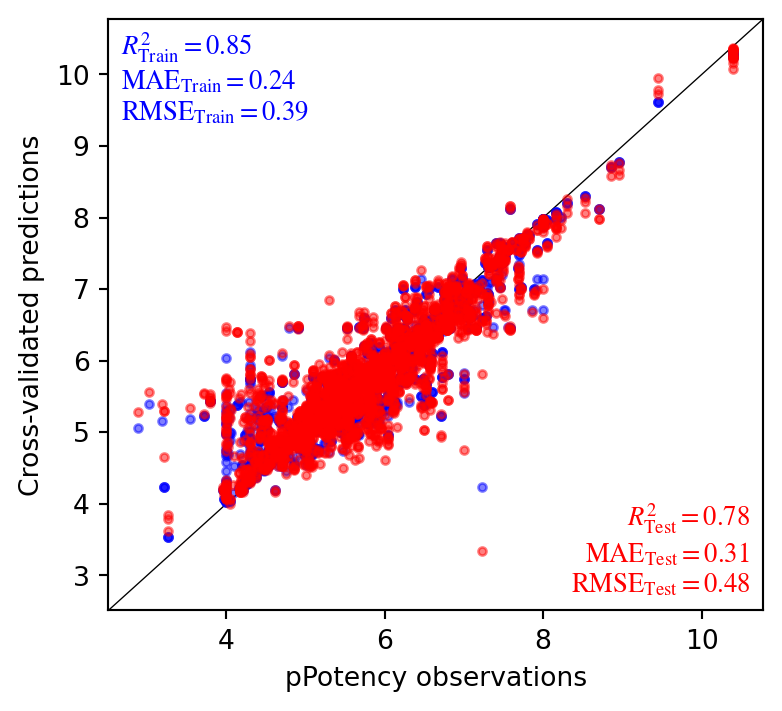

Saved parity plot for MACAW
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_MoLFormer_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_MoLFormer_CV.png


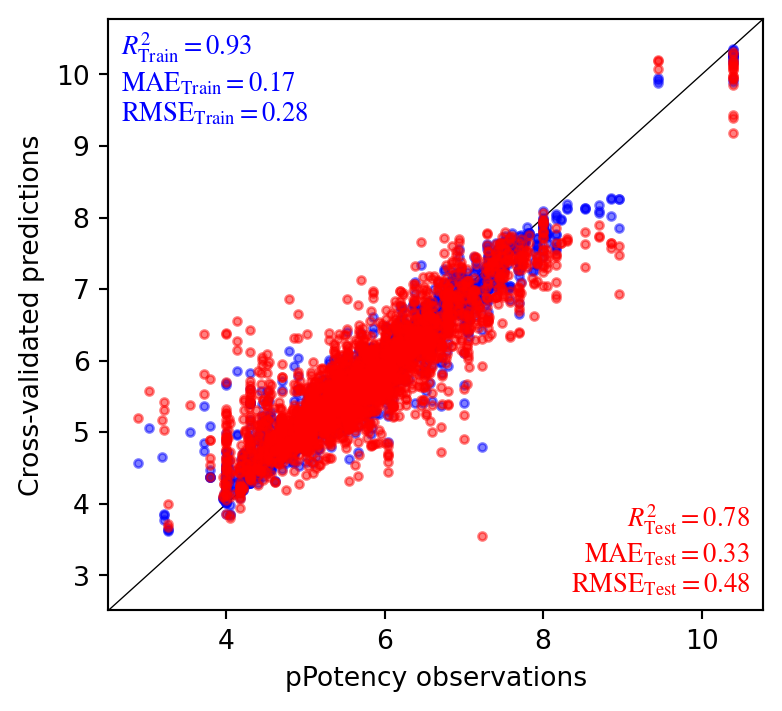

Saved parity plot for MoLFormer
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_MIST_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_MIST_CV.png


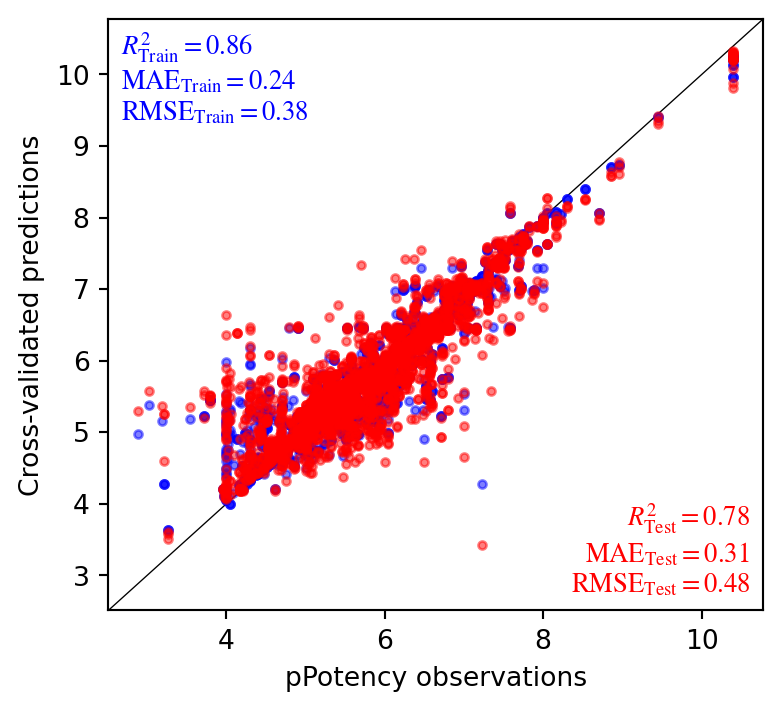

Saved parity plot for MIST
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_ChemBERTa_CV.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_ART_ChemBERTa_CV.png


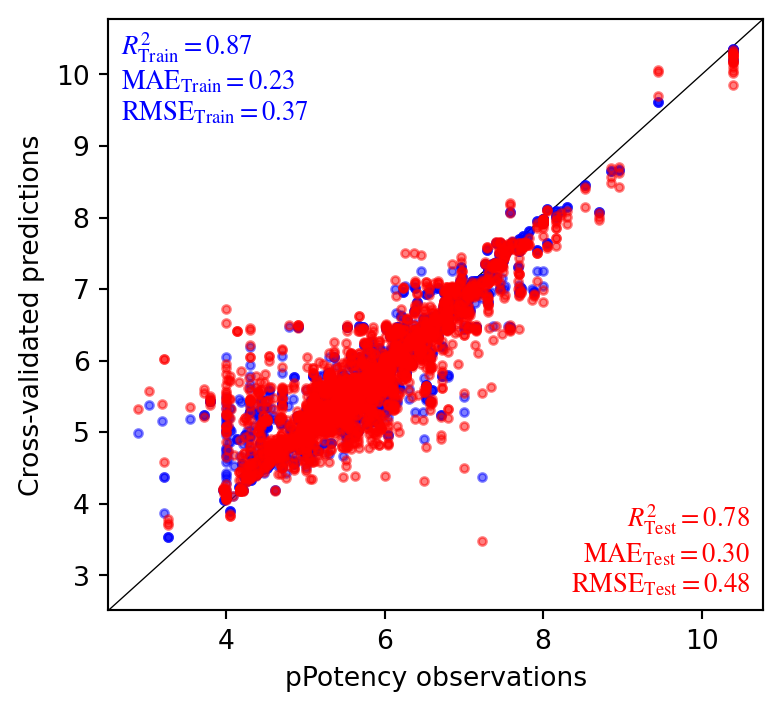

Saved parity plot for ChemBERTa


In [10]:
for embLabel, modelPath in artModelPaths.items():
    if not os.path.isfile(modelPath):
        print(f"[skip] {embLabel}: not found"); continue
    with open(modelPath,"rb") as h: artModel = cloudpickle.load(h)
    artModel.output_dir = resultsDir
    respVar    = artModel.response_vars[0]
    xTr        = artModel.df["Input Variables"][artModel.input_vars].values
    yObs       = artModel.df["Response Variables"][respVar].values
    yPredMean, _ = artModel.post_pred_stats(xTr)
    yPred      = yPredMean[:,0]
    cvDf       = artModel.model_prediction_cv_dfs[0]
    yPredCv    = np.array(cvDf.loc["Ensemble Model (L1)","Predictions"])
    parity_plot(x=yObs, y=yPred, x_test=yObs.copy(), y_test=yPredCv,
        xlabel="pPotency observations", ylabel="Cross-validated predictions",
        savetitle=os.path.join(resultsDir, f"{target}_ART_{embLabel}_CV.svg"),
        save_formats=["svg","png"])
    print(f"Saved parity plot for {embLabel}")

## 4.1 FDA-approved antivirals (DrugBank)

In [11]:
fdaAntiviralDF = pd.read_csv(drugBankFDAFile, dtype=str)
fdaAntiviralDF = fdaAntiviralDF[["smiles","ATC_code","Drug_Type"]].copy()
fdaAntiviralDF["Canonical_SMILES"] = fdaAntiviralDF["smiles"].apply(canonicalizeSmiles)
fdaAntiviralDF = fdaAntiviralDF.drop(columns=["smiles"])
fdaAntiviralDF = removeOverlap(fdaAntiviralDF,"Canonical_SMILES",trainingSmilesSet,"FDA antivirals:")
fdaAntiviralDF

FDA antivirals: overlap removed: 1 | remaining: 76


,ATC_code,Drug_Type,Canonical_SMILES
0,J05AF;J05AR,antiviral,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1
1,J05AB,antiviral,Nc1nc(=O)c2ncn(COCCO)c2[nH]1
2,J05AF,antiviral,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...
3,J05AE,antiviral,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...
4,J05AP,antiviral,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...
...,...,...,...
71,J05AB,antiviral,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O
72,J05AP,antiviral,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...
73,J05AF,antiviral,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1
74,J05AH,antiviral,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...


In [12]:
fdaAntiviralDF_wMACAW = macawEmbed(fdaAntiviralDF,"Canonical_SMILES",macawTransformer)
fdaAntiviralDF_wMACAW.to_csv(os.path.join(resultsDir,"fdaAntiviralDF_wMACAW.csv"),index=False)
fdaAntiviralDF_wART = artPredict(fdaAntiviralDF_wMACAW, art_macaw, ["Canonical_SMILES","Drug_Type"])
fdaAntiviralDF_wART.to_csv(os.path.join(resultsDir,"fdaAntiviralDF_wART.csv"),index=False)
showRange(fdaAntiviralDF_wART,"FDA antivirals:")
fdaAntiviralDF_wART

[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:47] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:48] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:48] DEPRECATION WARNING: please use AtomPairGenerator
[08:40:48] DEPRECATION W

FDA antivirals: pPotency 5.11±0.48 – 6.63±0.47


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005
...,...,...,...,...,...,...,...,...,...
71,CC(C)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@H](n...,antiviral,5.157025,0.475299,4.225440,6.088610,6.965867e-06,8.154363e-07,0.000060
72,CN(C)CCOCC(=O)NC12CC3CC(CC(C3)C1)C2,antiviral,5.146557,0.478147,4.209389,6.083725,7.135807e-06,8.246596e-07,0.000062
73,CC(C)[C@H](N)C(=O)OCCOCn1cnc2c(=O)nc(N)[nH]c21,antiviral,5.122079,0.478454,4.184309,6.059849,7.549542e-06,8.712659e-07,0.000065
74,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,antiviral,5.116885,0.481782,4.172592,6.061179,7.640375e-06,8.686028e-07,0.000067


In [13]:
fdaAntiviralDF_wART_wADMET = computeAdmet(fdaAntiviralDF_wART,"Canonical_SMILES")
fdaAntiviralDF_wART_wADMET = retainEndpoints(fdaAntiviralDF_wART_wADMET,["Canonical_SMILES","Drug_Type"])
fdaAntiviralDF_wART_wADMET.to_csv(os.path.join(resultsDir,"fdaAntiviralDF_wART_wADMET.csv"),index=False)
print("FDA antiviral final shape:", fdaAntiviralDF_wART_wADMET.shape)
fdaAntiviralDF_wART_wADMET.head()

model ensembles:   0%|                                                                                               | 0/2 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Output()

Output()

Output()

...

Output()

Output()

model ensembles: 100%|███████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.08s/it]


FDA antiviral final shape: (76, 42)


,Canonical_SMILES,Drug_Type,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,antiviral,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,0.473479,...,0.277044,0.757844,0.001464,0.091504,0.089238,0.112458,0.049566,0.061976,0.630507,0.594246
1,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,antiviral,6.421459,0.473641,5.493123,7.349796,3.789141e-07,4.468939e-08,0.000003,0.402790,...,0.828310,0.719191,0.000117,0.095870,0.049874,0.261650,0.025222,0.006694,0.876515,0.975297
2,CC(C)(C)[C@@H]1NC(=O)O[C@@H]2CCC[C@H]2OC/C=C/C...,antiviral,6.360733,0.474828,5.430070,7.291396,4.357794e-07,5.112152e-08,0.000004,0.402193,...,0.566219,0.692124,0.000146,0.062885,0.067880,0.181337,0.019857,0.011510,0.771802,0.868724
3,COC(=O)N[C@H](C(=O)N1CCC[C@H]1C(=O)Nc1ccc([C@@...,antiviral,6.231433,0.474520,5.301375,7.161492,5.869038e-07,6.894589e-08,0.000005,0.110028,...,0.472612,0.741510,0.000094,0.232419,0.103702,0.511647,0.014375,0.013199,0.846098,0.938079
4,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc2cc([C@H]3CC...,antiviral,6.192363,0.472963,5.265355,7.119371,6.421502e-07,7.596762e-08,0.000005,0.078322,...,0.677893,0.716190,0.000045,0.234808,0.075199,0.690765,0.026800,0.019639,0.937238,0.997227


### Withdrawn drugs — ADMET only

## 4.2 Reference drugs

In [14]:
referenceDrugsDF = pd.DataFrame([{"drugName":k,"Canonical_SMILES":canonicalizeSmiles(v)}
                                    for k,v in ReferenceDrugs.items()])
referenceDrugsDF = removeOverlap(referenceDrugsDF,"Canonical_SMILES",trainingSmilesSet,"Reference drugs:")
referenceDrugsDF

Reference drugs: overlap removed: 0 | remaining: 4


,drugName,Canonical_SMILES
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...
2,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O
3,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...


In [15]:
referenceDrugsDF_wMACAW       = macawEmbed(referenceDrugsDF,"Canonical_SMILES",macawTransformer)
referenceDrugsDF_ARTprediction = artPredict(referenceDrugsDF_wMACAW,art_macaw,["Canonical_SMILES","drugName"])
referenceDrugsDF_ARTprediction.to_csv(os.path.join(resultsDir,"referenceDrugsDF_ARTprediction.csv"),index=False)
referenceDrugsDF_ARTprediction[["Canonical_SMILES"]].to_csv(
    os.path.join(resultsDir,"referenceDrugsDF_ARTprediction_SMILES.csv"),index=False)
showRange(referenceDrugsDF_ARTprediction,"Reference drugs:")
referenceDrugsDF_ARTprediction

[08:41:39] DEPRECATION WARNING: please use AtomPairGenerator
[08:41:39] DEPRECATION WARNING: please use AtomPairGenerator
[08:41:39] DEPRECATION WARNING: please use AtomPairGenerator
[08:41:39] DEPRECATION WARNING: please use AtomPairGenerator


Reference drugs: pPotency 4.91±0.48 – 6.63±0.47


,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.503281,0.471096,4.579933,6.426628,3.138479e-06,3.744309e-07,0.000026
2,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,Molnupiravir,5.244613,0.477223,4.309255,6.179970,5.693607e-06,6.607385e-07,0.000049
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.908812,0.481485,3.965101,5.852524,1.233637e-05,1.404352e-06,0.000108


Sampling: [y]


Molecule 1: mean=6.62 std=0.48 95%CI=[5.69,7.54] IC50=0.2400µM


Sampling: [y]


Molecule 2: mean=5.51 std=0.48 95%CI=[4.60,6.44] IC50=3.0968µM


Sampling: [y]
Sampling: [y]


Molecule 3: mean=5.24 std=0.48 95%CI=[4.29,6.17] IC50=5.8155µM
Molecule 4: mean=4.92 std=0.48 95%CI=[3.99,5.84] IC50=12.0927µM


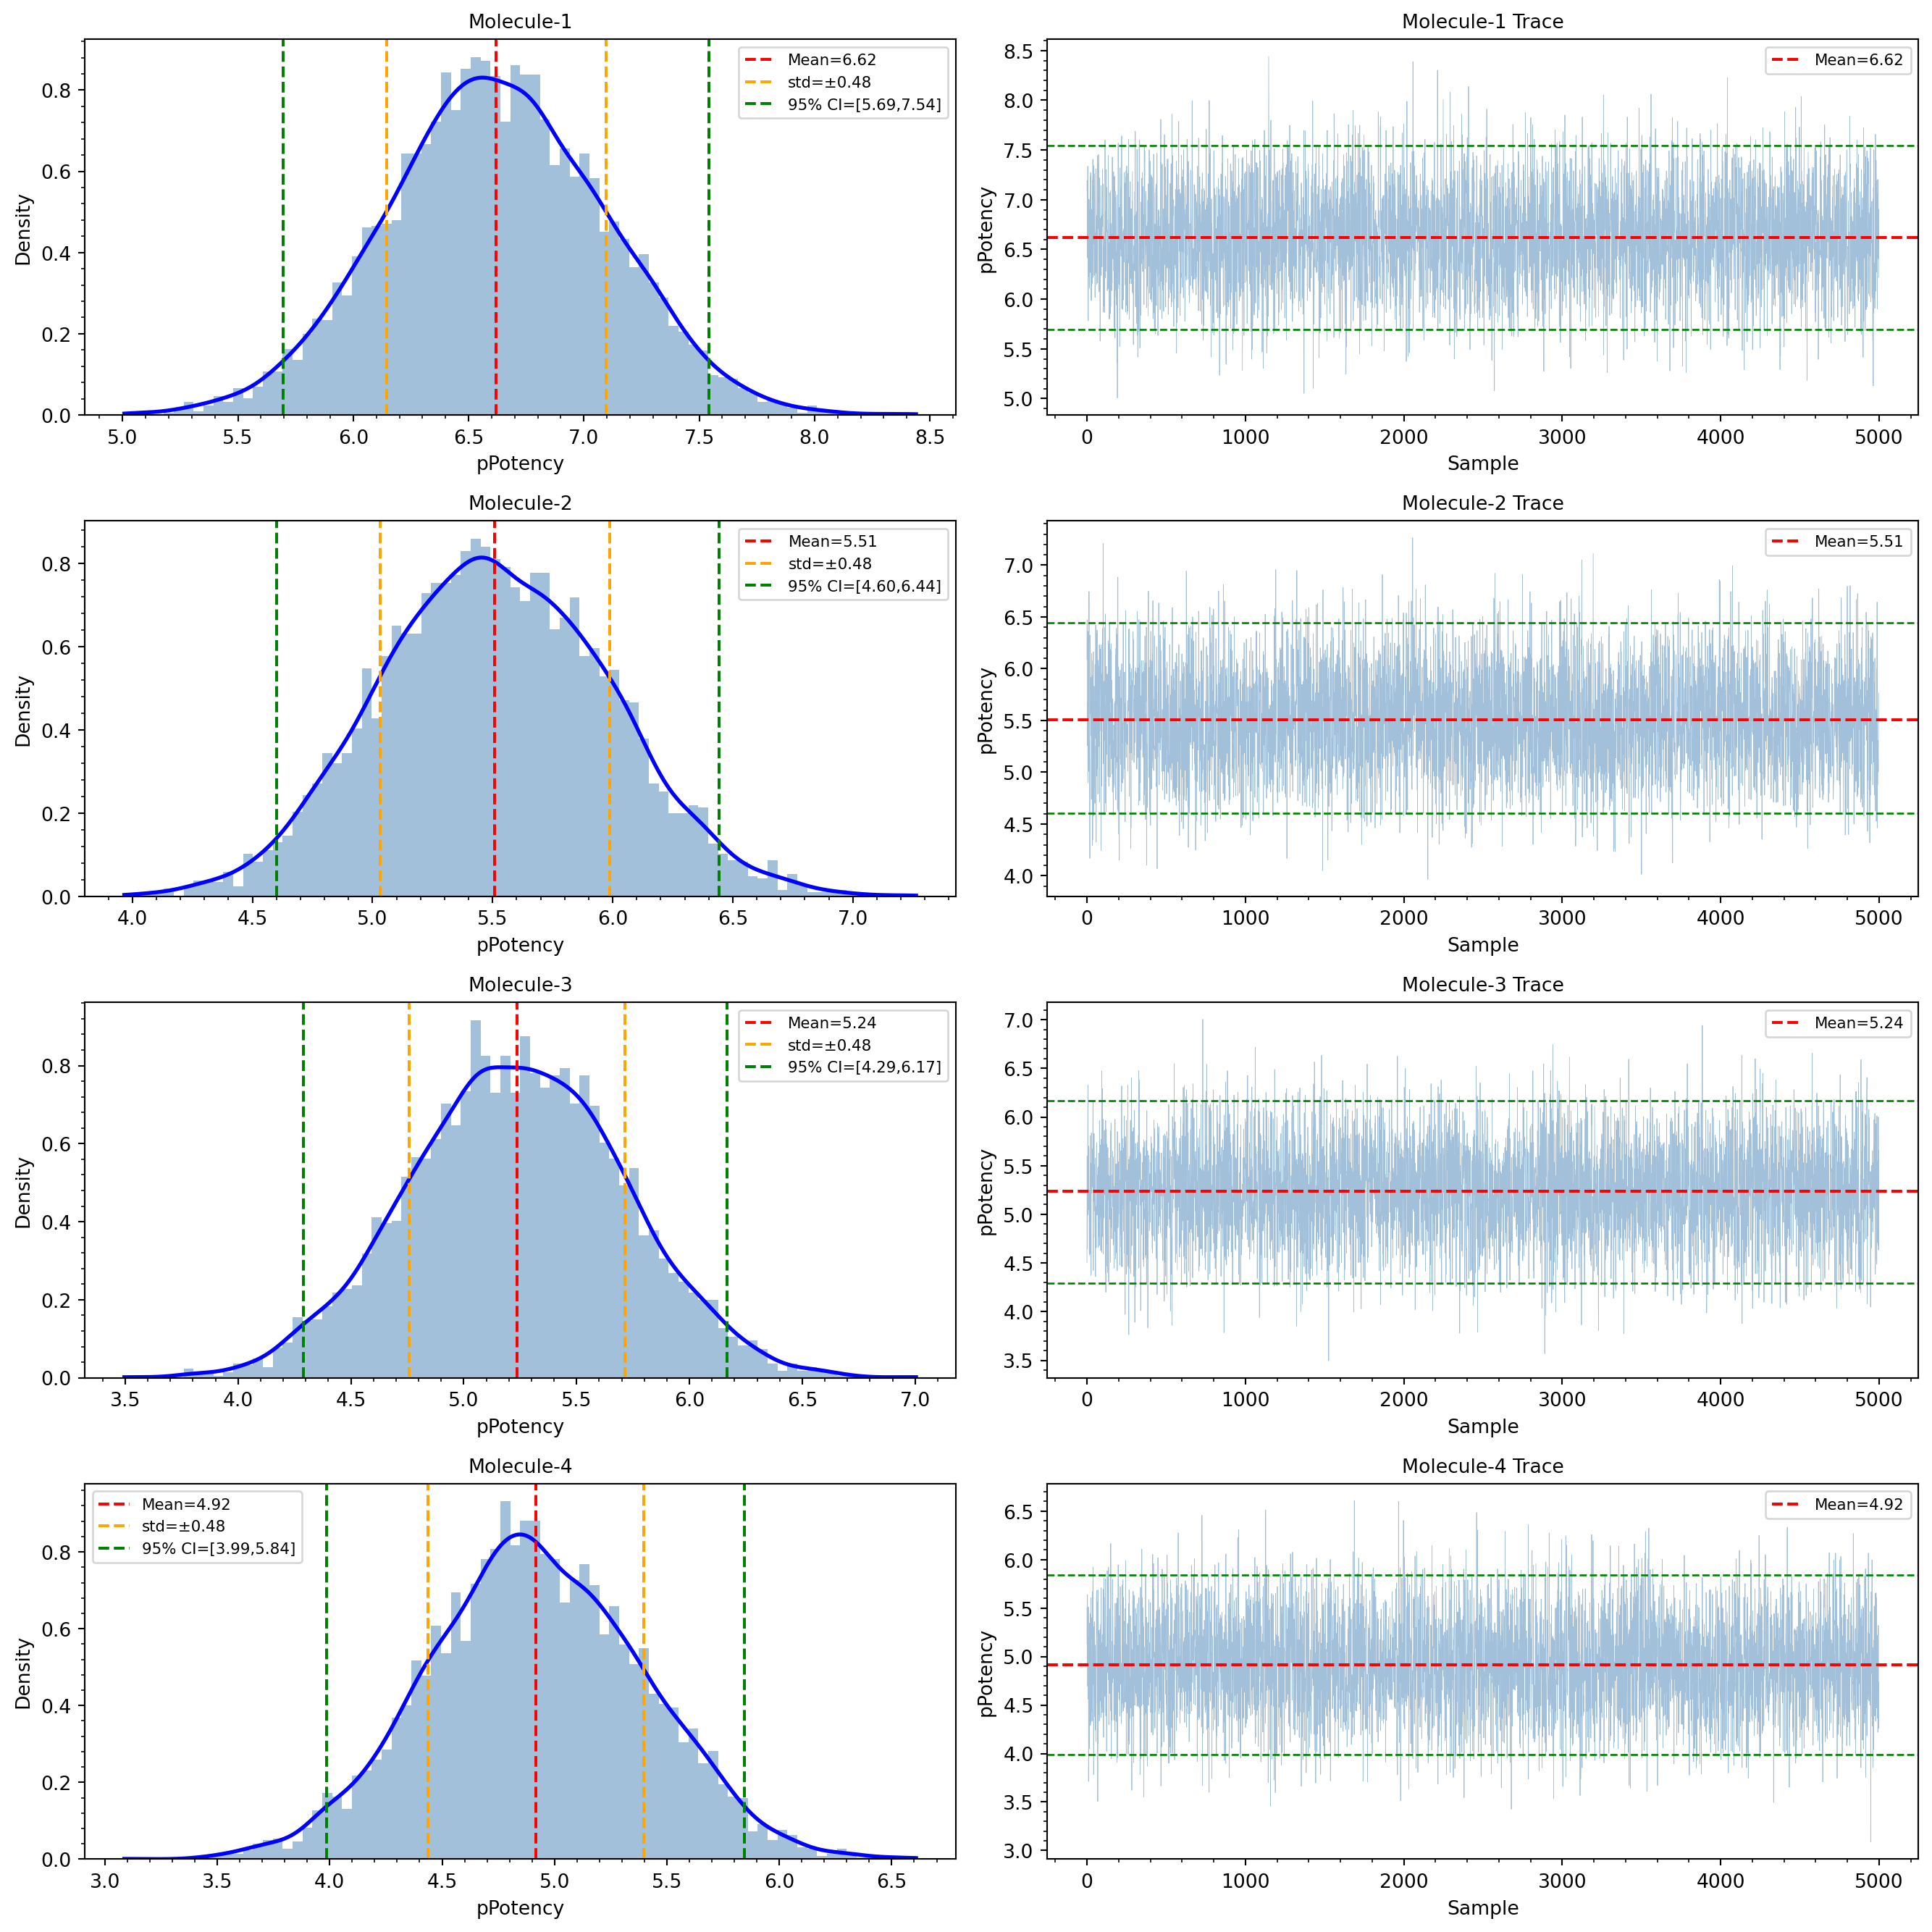

In [16]:
def plotPotencyFromDraws(predDf, featDf, art, n=5, nSamples=5000, savePrefix=""):
    macawCols = [c for c in featDf.columns if c.startswith("MACAW_")]
    merged = (predDf.nlargest(n,"pPotency_prediction")
                     .merge(featDf[["Canonical_SMILES",*macawCols]],on="Canonical_SMILES",how="inner"))
    if merged.empty: print("No molecules to plot."); return
    fig, axes = plt.subplots(len(merged),2,figsize=(14,3.5*len(merged)),squeeze=False)
    for i,(_,row) in enumerate(merged.iterrows()):
        x     = row[macawCols].to_numpy(dtype=float).reshape(1,-1)
        draws = np.asarray(art.post_pred_draws(x,n_samples=nSamples)).ravel()
        if draws.size < 2: continue
        mu,sg = draws.mean(), draws.std()
        lo,hi = np.percentile(draws,[2.5,97.5])
        ax0   = axes[i,0]
        ax0.hist(draws,bins=min(80,max(1,len(draws)//2)),density=True,alpha=0.5,color="steelblue")
        try:
            kde=gaussian_kde(draws); xr=np.linspace(draws.min(),draws.max(),500)
            ax0.plot(xr,kde(xr),"b-",lw=2)
        except Exception: pass
        ax0.axvline(mu,color="red",linestyle="--",label=f"Mean={mu:.2f}")
        ax0.axvline(mu-sg,color="orange",linestyle="--",lw=1.5)
        ax0.axvline(mu+sg,color="orange",linestyle="--",lw=1.5,label=f"std=±{sg:.2f}")
        ax0.axvline(lo,color="green",linestyle="--",label=f"95% CI=[{lo:.2f},{hi:.2f}]")
        ax0.axvline(hi,color="green",linestyle="--")
        ax0.set_xlabel("pPotency"); ax0.set_ylabel("Density"); ax0.legend(fontsize=8)
        ax0.set_title(f"Molecule-{i+1}")
        ax0.xaxis.set_minor_locator(AutoMinorLocator(5)); ax0.yaxis.set_minor_locator(AutoMinorLocator(5))
        ax1 = axes[i,1]
        ax1.plot(draws,alpha=0.5,lw=0.3,color="steelblue")
        ax1.axhline(mu,color="red",linestyle="--",lw=1.5,label=f"Mean={mu:.2f}")
        ax1.axhline(lo,color="green",linestyle="--",lw=1)
        ax1.axhline(hi,color="green",linestyle="--",lw=1)
        ax1.set_xlabel("Sample"); ax1.set_ylabel("pPotency"); ax1.legend(fontsize=8)
        ax1.set_title(f"Molecule-{i+1} Trace")
        ax1.xaxis.set_minor_locator(AutoMinorLocator(5)); ax1.yaxis.set_minor_locator(AutoMinorLocator(5))
        print(f"Molecule {i+1}: mean={mu:.2f} std={sg:.2f} 95%CI=[{lo:.2f},{hi:.2f}] IC50={10**(-mu)*1e6:.4f}µM")
    plt.tight_layout()
    if savePrefix:
        plt.savefig(os.path.join(resultsDir,f"{savePrefix}_ARTprobability.png"),dpi=300,bbox_inches="tight")
    plt.show()

plotPotencyFromDraws(referenceDrugsDF_ARTprediction, referenceDrugsDF_wMACAW,
                     art_macaw, n=len(referenceDrugsDF_ARTprediction), savePrefix="referenceDrugs")

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/referenceDrugsDF_wARTprediction_grid.png


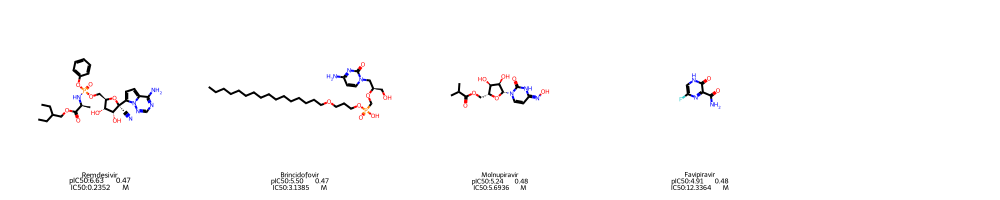

In [17]:
df = referenceDrugsDF_ARTprediction.copy()
p_arr   = df["pPotency_prediction"].values
std_arr = df["pPotency_std"].values if "pPotency_std" in df.columns else np.full(len(df),np.nan)
ic50_arr= 10**(-p_arr)*1e6; drug_arr=df["drugName"].values; smi_arr=df["Canonical_SMILES"].values

mols,legs=[],[]
for smi,drug,pp,ic,ss in zip(smi_arr,drug_arr,p_arr,ic50_arr,std_arr):
    mol=Chem.MolFromSmiles(smi)
    if mol is None: continue
    label=(f"{drug}\npIC50:{pp:.2f}±{ss:.2f}\nIC50:{ic:.4f}µM" if pd.notna(ss)
           else f"{drug}\npIC50:{pp:.2f}\nIC50:{ic:.4f}µM")
    mols.append(mol); legs.append(label)

outPng=os.path.join(resultsDir,"referenceDrugsDF_wARTprediction_grid.png")
outSvg=os.path.join(resultsDir,"referenceDrugsDF_wARTprediction_grid.svg")
png=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=False,returnPNG=True)
svg=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=True)
with open(outPng,"wb") as fh: fh.write(png.data if hasattr(png,"data") else png)
with open(outSvg,"w")  as fh: fh.write(svg.data if hasattr(svg,"data") else svg)
print("Saved:",outPng); display(png)

In [18]:
referenceDrugsDF_wART_wADMET = computeAdmet(referenceDrugsDF_ARTprediction,"Canonical_SMILES")
referenceDrugsDF_wART_wADMET = retainEndpoints(referenceDrugsDF_wART_wADMET,["Canonical_SMILES","drugName"])
referenceDrugsDF_wART_wADMET.to_csv(os.path.join(resultsDir,"referenceDrugsDF_wART_wADMET.csv"),index=False)
referenceDrugsDF_wART_wADMET

model ensembles:   0%|                                                                                               | 0/2 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

model ensembles: 100%|███████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.57it/s]


,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,0.473479,...,0.277044,0.757844,0.001464,0.091504,0.089238,0.112458,0.049566,0.061976,0.630507,0.594246
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.503281,0.471096,4.579933,6.426628,3.138479e-06,3.744309e-07,0.000026,0.101981,...,0.842036,0.629167,0.010197,0.157190,0.191498,0.206246,0.250503,0.085742,0.808944,0.773347
2,CC(C)C(=O)OC[C@H]1O[C@@H](n2cc/c(=N/O)[nH]c2=O...,Molnupiravir,5.244613,0.477223,4.309255,6.179970,5.693607e-06,6.607385e-07,0.000049,0.763421,...,0.036468,0.494893,0.002084,0.026884,0.029360,0.009055,0.017086,0.023927,0.209236,0.004572
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.908812,0.481485,3.965101,5.852524,1.233637e-05,1.404352e-06,0.000108,0.320588,...,0.658438,0.941233,0.149382,0.005008,0.279543,0.002740,0.068533,0.001683,0.221323,0.000365


## 4.3 DORAnet-generated compounds

In [20]:
starterFiles = sorted(glob.glob(os.path.join(resultsDir,"*_generated_compounds.csv")))
starterFiles = [f for f in starterFiles if "_highFeasibility" not in f]
print(f"Found {len(starterFiles)} starter files:")

dfList=[]
for filePath in starterFiles:
    starterName = os.path.basename(filePath).replace("_generated_compounds.csv","")
    df = pd.read_csv(filePath,dtype=str); df["Starter_Name"]=starterName
    print(f"  {starterName}: {len(df)} compounds"); dfList.append(df)

generatedCompounds = pd.concat(dfList,ignore_index=True); del dfList; gc.collect()
smiColRaw = "Canonical_SMILES" if "Canonical_SMILES" in generatedCompounds.columns else "Target_Canonical_SMILES"
generatedCompounds = generatedCompounds.rename(columns={smiColRaw:"Canonical_SMILES"})
generatedCompounds = (generatedCompounds.dropna(subset=["Canonical_SMILES"])
    .drop_duplicates(subset="Canonical_SMILES",keep="first")
    .filter(items=["Starter_Name","starter_Canonical_SMILES","Canonical_SMILES"])
    .reset_index(drop=True))
gc.collect()
generatedCompounds.to_csv(os.path.join(resultsDir,f"{target}_allGeneratedCompounds_combined.csv"),index=False)
print(f"Combined after dedup: {len(generatedCompounds)}")
generatedCompounds

Found 6 starter files:
  Adenosine: 4045 compounds
  Brincidofovir: 2932 compounds
  Guanosine: 3962 compounds
  Inosine: 4122 compounds
  Remdesivir: 618 compounds
  Xanthosine: 3398 compounds
Combined after dedup: 19017


,Starter_Name,starter_Canonical_SMILES,Canonical_SMILES
0,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](CO)[...
1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CCC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](CO)...
2,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@H]1O[C@H](C(C)...
3,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,COC[C@H]1O[C@@H](n2cnc3c(N(C(C)=O)C(N)=O)ncnc3...
4,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)N(C(N)=O)c1ncnc2c1ncn2[C@@]1(C)O[C@H](CO...
...,...,...,...
19012,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32)[C@...
19013,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H]([C@H](n3cnc4c(=O)[nH]c(=O)[nH]c...
19014,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@H]1O[C@@]2(n3cnc4c(=O)[nH]c(=O)[nH]c43)O[C...
19015,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,C[C@]12O[C@@H](n3cnc4c(=O)[nH]c(=O)[nH]c43)[C@...


In [21]:
generatedCompounds = removeOverlap(generatedCompounds,"Canonical_SMILES",trainingSmilesSet,"Generated:")
generatedCompounds_wMACAW = macawEmbed(generatedCompounds,"Canonical_SMILES",macawTransformer)
generatedCompounds_wMACAW.to_csv(
    os.path.join(resultsDir,f"{target}_allGeneratedCompounds_wMACAW.csv"),index=False)
print(f"Embedded shape: {generatedCompounds_wMACAW.shape}")

Generated: overlap removed: 1 | remaining: 19,016


[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION WARNING: please use AtomPairGenerator
[08:42:52] DEPRECATION W

Embedded shape: (19016, 63)


In [22]:
idColsGen = [c for c in ["Starter_Name","starter_Canonical_SMILES","Canonical_SMILES"]
              if c in generatedCompounds_wMACAW.columns]
generatedCompounds_ARTprediction = artPredict(generatedCompounds_wMACAW,art_macaw,idColsGen)
generatedCompounds_ARTprediction.to_csv(
    os.path.join(resultsDir,f"{target}_allGeneratedCompounds_ARTprediction.csv"),index=False)
generatedCompounds_ARTprediction[["Canonical_SMILES"]].to_csv(
    os.path.join(resultsDir,f"{target}_allGeneratedCompounds_ARTprediction_SMILES.csv"),index=False)
showRange(generatedCompounds_ARTprediction,"Generated:"); generatedCompounds_ARTprediction

Generated: pPotency 4.36±0.47 – 5.77±0.47


,Starter_Name,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CCC(CC)CC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(=...,5.767021,0.473937,4.838103,6.695938,0.000002,2.014012e-07,0.000015
1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.757650,0.479591,4.817652,6.697648,0.000002,2.006096e-07,0.000015
2,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,O=C(O)c1ccccc1,5.748711,0.474997,4.817718,6.679705,0.000002,2.090716e-07,0.000015
3,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Oc1ccccc1,5.746977,0.474793,4.816382,6.677572,0.000002,2.101008e-07,0.000015
4,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,CC(C)=CCc1ccccc1O,5.723254,0.471339,4.799430,6.647078,0.000002,2.253834e-07,0.000016
...,...,...,...,...,...,...,...,...,...,...
19011,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCCCCOCCC=O,4.785476,0.482511,3.839755,5.731198,0.000016,1.856959e-06,0.000145
19012,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCOCCCO,4.775668,0.483916,3.827194,5.724143,0.000017,1.887371e-06,0.000149
19013,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCOCCCO,4.754977,0.484155,3.806034,5.703920,0.000018,1.977334e-06,0.000156
19014,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,CCCCCCCCCCOCCC=O,4.750124,0.481088,3.807191,5.693057,0.000018,2.027414e-06,0.000156


### Per-starter summary

In [23]:
if "Starter_Name" in generatedCompounds_ARTprediction.columns and not generatedCompounds_ARTprediction.empty:
    df=generatedCompounds_ARTprediction; grp=df.groupby("Starter_Name")
    maxRows=df.loc[grp["pPotency_prediction"].idxmax()].set_index("Starter_Name")
    minRows=df.loc[grp["pPotency_prediction"].idxmin()].set_index("Starter_Name")
    summary=pd.DataFrame(index=grp.size().index)
    summary["n_compounds"]          = grp.size().astype(int)
    summary["pPotency_max (±std)"]  = maxRows.apply(lambda r:f"{r['pPotency_prediction']:.2f}±{r['pPotency_std']:.2f}",axis=1)
    summary["pPotency_min (±std)"]  = minRows.apply(lambda r:f"{r['pPotency_prediction']:.2f}±{r['pPotency_std']:.2f}",axis=1)
    summary["IC50_M_max"]           = grp["IC50(M)_prediction"].max()
    summary["IC50_M_min"]           = grp["IC50(M)_prediction"].min()
    summary=(summary.assign(_s=maxRows["pPotency_prediction"]).sort_values("_s",ascending=False)
             .drop(columns="_s").reset_index())
    summary=summary[["Starter_Name","n_compounds","pPotency_max (±std)","pPotency_min (±std)","IC50_M_max","IC50_M_min"]]
    display(summary)

,Starter_Name,n_compounds,pPotency_max (±std),pPotency_min (±std),IC50_M_max,IC50_M_min
0,Remdesivir,610,5.77±0.47,5.01±0.48,0.000010,0.000002
1,Adenosine,4045,5.76±0.48,4.36±0.47,0.000044,0.000002
2,Guanosine,3936,5.69±0.48,5.00±0.48,0.000010,0.000002
3,Brincidofovir,2929,5.67±0.47,4.75±0.48,0.000018,0.000002
4,Inosine,4110,5.67±0.47,4.94±0.48,0.000011,0.000002
5,Xanthosine,3386,5.58±0.47,5.05±0.48,0.000009,0.000003


### SVR cross-validation (random and scaffold-grouped)

In [24]:
svrSmiles = trainingData["Canonical_SMILES"]
svrTarget = pd.to_numeric(trainingData["pPotency"],errors="coerce")
validMask = svrTarget.notna()
svrSmiles = svrSmiles[validMask].reset_index(drop=True)
svrTarget = svrTarget[validMask].reset_index(drop=True)
macawNComponents = getattr(macawTransformer,"n_components",15)
macawNLandmarks  = getattr(macawTransformer,"n_landmarks",100)

def getScaffoldGroups(series):
    groups=[]
    for idx,smi in enumerate(series):
        try: core=MurckoScaffold.MurckoScaffoldSmiles(smiles=str(smi),includeChirality=False)
        except: core=""
        groups.append(core if core else f"singleton_{idx}")
    return np.array(groups)

def runSvrFold(trIdx,teIdx):
    smiTr,smiTe = svrSmiles.iloc[trIdx].tolist(), svrSmiles.iloc[teIdx].tolist()
    yTr, yTe    = svrTarget.iloc[trIdx].values.astype(float), svrTarget.iloc[teIdx].values.astype(float)
    mcwF = MACAW(type_fp="atompairs",metric="sokal",n_components=macawNComponents,
                 n_landmarks=macawNLandmarks,random_state=42)
    mcwF.fit(smiTr,yTr)
    xTr = np.asarray(mcwF.transform(smiTr),dtype=np.float32)
    xTe = np.asarray(mcwF.transform(smiTe),dtype=np.float32)
    grid = GridSearchCV(SVR(),paramGrid,cv=5,refit=True,n_jobs=1)
    grid.fit(xTr,yTr)
    return teIdx, grid.predict(xTe), yTe

def runSvrCv(name,splits):
    results   = Parallel(n_jobs=4)(delayed(runSvrFold)(tr,te) for tr,te in splits)
    oof       = np.full(len(svrTarget),np.nan)
    for teIdx,pred,_ in results: oof[teIdx]=pred
    scored    = ~np.isnan(oof)
    r2  = r2_score(svrTarget.values[scored],oof[scored])
    rmse= np.sqrt(mean_squared_error(svrTarget.values[scored],oof[scored]))
    mae = mean_absolute_error(svrTarget.values[scored],oof[scored])
    print(f"{name}: R²={r2:.2f} RMSE={rmse:.2f} MAE={mae:.2f} scored={scored.sum()}")
    return {"Split":name,"R2":r2,"RMSE":rmse,"MAE":mae}

print(f"SVR {nSplits}-fold CV on {len(svrTarget)} labeled molecules")
scaffoldGroups = getScaffoldGroups(svrSmiles)
randomSplits   = list(KFold(n_splits=nSplits,shuffle=True,random_state=42).split(svrSmiles))
scaffoldSplits = list(GroupKFold(n_splits=nSplits).split(svrSmiles,groups=scaffoldGroups))
outOfFoldCvDF  = pd.DataFrame([runSvrCv("Random KFold",randomSplits),
                                runSvrCv("Scaffold GroupKFold",scaffoldSplits)])
outOfFoldCvDF

SVR 10-fold CV on 2704 labeled molecules


I0000 00:00:1789141470.153915 2599215 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789141470.206822 2599215 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789141470.395811 2599213 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789141470.395811 2599212 port.cc:153] oneDNN custo

Random KFold: R²=0.68 RMSE=0.57 MAE=0.40 scored=2704


[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION WARNING: please use AtomPairGenerator
[08:44:43] DEPRECATION W

Scaffold GroupKFold: R²=0.42 RMSE=0.77 MAE=0.58 scored=2704


,Split,R2,RMSE,MAE
0,Random KFold,0.682636,0.572928,0.398729
1,Scaffold GroupKFold,0.421684,0.773399,0.584802


### Top-N compounds by predicted pPotency

In [26]:
# Exclude compounds derived from reference drug starters.
startetsToExclude = {"Remdesivir", "Brincidofovir"}

In [27]:
mask = ~generatedCompounds_ARTprediction["Starter_Name"].isin(startetsToExclude)
filtered = generatedCompounds_ARTprediction[mask].reset_index(drop=True)

p_arr   = filtered["pPotency_prediction"].values
topNIdx = np.argsort(p_arr)[::-1][:topN]
generatedCompounds_wARTprediction_topN = filtered.iloc[topNIdx].copy()
generatedCompounds_wARTprediction_topN["pPotency_prediction"] = p_arr[topNIdx].round(3)
generatedCompounds_wARTprediction_topN["IC50 (µM)"]           = 10**(-p_arr[topNIdx])*1e6
generatedCompounds_wARTprediction_topN.insert(0,"Rank",range(1,topN+1))
pmax,pmin = p_arr[topNIdx[0]], p_arr[topNIdx[-1]]
print(f"Excluded starters: {startetsToExclude}")
print(f"Remaining compounds: {len(filtered):,}")
print(f"Top {topN}: pPotency {pmin:.2f}-{pmax:.2f} | IC50 {10**(-pmax)*1e6:.4f}-{10**(-pmin)*1e6:.4f}µM")

dispCols = [c for c in ["Rank","Starter_Name","starter_Canonical_SMILES","Canonical_SMILES",
                         "pPotency_prediction","pPotency_std","IC50 (µM)"]
            if c in generatedCompounds_wARTprediction_topN.columns]
generatedCompounds_wARTprediction_topN = generatedCompounds_wARTprediction_topN[dispCols]
generatedCompounds_wARTprediction_topN

Excluded starters: {'Remdesivir', 'Brincidofovir'}
Remaining compounds: 15,477
Top 20: pPotency 5.61-5.76 | IC50 1.7472-2.4278µM


,Rank,Starter_Name,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
0,1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.758,0.479591,1.747229
1,2,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.693,0.478908,2.026785
2,3,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.692,0.473252,2.030622
3,4,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.683,0.471067,2.074770
4,5,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.679,0.476017,2.094051
5,6,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.677,0.471412,2.104081
6,7,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.670,0.471980,2.136730
7,8,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.669,0.470421,2.140884
8,9,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.667,0.470071,2.155065
9,10,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.664,0.478859,2.166036


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_generatedCompounds_top20.png


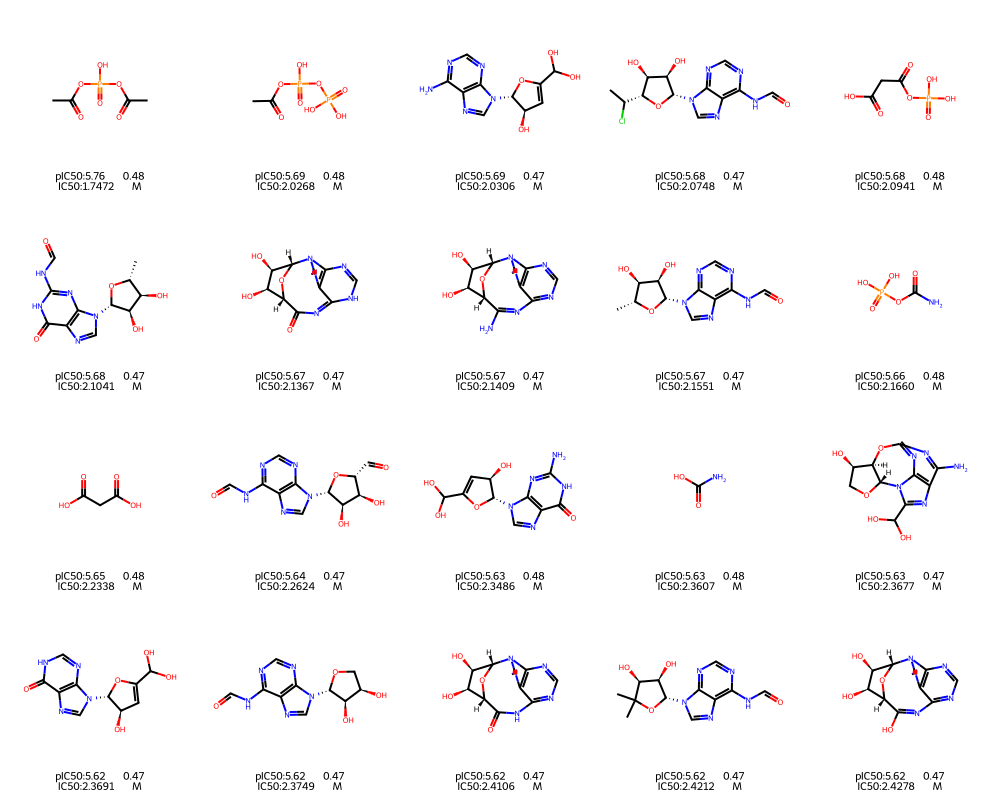

In [28]:
top = generatedCompounds_wARTprediction_topN.head(topN)
mols,legs=[],[]
for _,row in top.iterrows():
    mol=Chem.MolFromSmiles(row["Canonical_SMILES"])
    if mol is None: continue
    ss=row.get("pPotency_std",np.nan)
    label=(f"pIC50:{row['pPotency_prediction']:.2f}±{ss:.2f}\nIC50:{row['IC50 (µM)']:.4f}µM"
           if pd.notna(ss) else f"pIC50:{row['pPotency_prediction']:.2f}\nIC50:{row['IC50 (µM)']:.4f}µM")
    mols.append(mol); legs.append(label)

outPng=os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}.png")
outSvg=os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}.svg")
imgPng=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=False,returnPNG=True)
imgSvg=Draw.MolsToGridImage(mols,subImgSize=(200,200),molsPerRow=5,legends=legs,useSVG=True)
with open(outPng,"wb") as fh: fh.write(imgPng.data if hasattr(imgPng,"data") else imgPng)
with open(outSvg,"w")  as fh: fh.write(imgSvg.data if hasattr(imgSvg,"data") else imgSvg)
print("Saved:",outPng); display(imgPng)

In [29]:
mapping = generatedCompounds[["Canonical_SMILES","Starter_Name"]].drop_duplicates("Canonical_SMILES")
generatedCompounds_wARTprediction_topN = generatedCompounds_wARTprediction_topN.merge(mapping,on="Canonical_SMILES",how="left")
generatedCompounds_wARTprediction_topN.to_csv(
    os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}.csv"),index=False)
generatedCompounds_wARTprediction_topN[["Canonical_SMILES"]].to_csv(
    os.path.join(resultsDir,f"{target}_generatedCompounds_top{topN}_SMILESonly.csv"),index=False)
generatedCompounds_wARTprediction_topN

,Rank,Starter_Name_x,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),Starter_Name_y
0,1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.758,0.479591,1.747229,Adenosine
1,2,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.693,0.478908,2.026785,Guanosine
2,3,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.692,0.473252,2.030622,Adenosine
3,4,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.683,0.471067,2.074770,Adenosine
4,5,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.679,0.476017,2.094051,Guanosine
5,6,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.677,0.471412,2.104081,Guanosine
6,7,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.670,0.471980,2.136730,Inosine
7,8,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.669,0.470421,2.140884,Adenosine
8,9,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.667,0.470071,2.155065,Adenosine
9,10,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.664,0.478859,2.166036,Adenosine


### ADMET for all generated compounds

Two options are provided. For large compound sets (> 25,000 compounds) `Option A (command line)`
is strongly recommended: it batches predictions, writes a checkpoint after
every batch so a crashed run resumes where it left off, and optionally applies
a Tanimoto diversity filter before prediction.

`Option B (inline)` runs the same `ADMETModel` call synchronously with no
checkpointing. It is only practical for small sets.

The code cell below checks how many compounds are queued and prints an explicit
recommendation. The config YAML is written automatically, so you can go
straight to the terminal command.

#### Option A — command line

```bash
cd Results_{target}/Step4_ADMET
python runADMET.py ADMET_config_DORAnetMol.yaml > admet_DORAnetMol.out
```

Copy `runADMET.py` into `Step4_ADMET/` before running. Outputs:

- `{target}_generatedCompounds_wART_wADMET.csv` — full table with ADMET columns
- `{target}_generatedCompounds_wART_wADMET_checkpoint.csv` — per-batch checkpoint
- `{target}_generatedCompounds_wART_diverseInput.csv` — diversity-filtered input

#### Option B — inline (small sets only)

Set `useInlineADMET = True` in the cell below.

In [37]:
# Step4_ADMET holds the config YAML and the staged input copy.
admetDir = os.path.join(resultsDir, "Step4_ADMET")
os.makedirs(admetDir, exist_ok=True)

# The ART prediction file produced by the previous cell.
artPredFile = os.path.join(resultsDir, f"{target}_allGeneratedCompounds_ARTprediction.csv")

# Copy the ART file under a shorter stem so runADMET.py produces the exact
# output filename {target}_generatedCompounds_wART_wADMET.csv.
admetInputFile = os.path.join(admetDir, f"{target}_generatedCompounds_wART.csv")
shutil.copy2(artPredFile, admetInputFile)

# All runADMET.py outputs land in resultsDir so the final CSV sits alongside
# the other Step 4 tables in Results_Ebola/.
admetOutputFile     = os.path.join(resultsDir, f"{target}_generatedCompounds_wART_wADMET.csv")
admetCheckpointFile = os.path.join(resultsDir, f"{target}_generatedCompounds_wART_wADMET_checkpoint.csv")
admetDiverseFile    = os.path.join(resultsDir, f"{target}_generatedCompounds_wART_diverseInput.csv")

# Count compounds and recommend a route.
nCompounds = len(generatedCompounds_ARTprediction)
CMDLINE_THRESHOLD = 25_000
print(f"Compounds listed for ADMET prediction: {nCompounds:,}")
if nCompounds > CMDLINE_THRESHOLD:
    print(f"  > {CMDLINE_THRESHOLD:,} compounds detected — command line (Option A) is strongly recommended.")
    print("  Inline prediction at this scale is slow and has no fault tolerance.")
else:
    print(f"  <= {CMDLINE_THRESHOLD:,} compounds — either option will work.")

# Write the ADMET config YAML into Step4_ADMET/.
admetConfig = {
    "inputFile":                  admetInputFile,
    "outputDir":                  resultsDir,         # final CSV written to Results_Ebola/
    "SMILES_Column":              "Canonical_SMILES",
    "selectSMILES":               None,
    "batchSize":                  500,
    "saveEveryBatch":             True,
    "resumeFromCheckpoint":       True,
    "deduplicateSmiles":          True,
    "enableDiversityFilter":      True,
    "similarityThreshold":        1.0,
    "fingerprintRadius":          2,
    "fingerprintBits":            2048,
    "diversityChunkSize":         1000,
    "saveDiversityFilteredInput": True,
    "diversityOutputSuffix":      "_diverseInput",
    "useCanonicalFiltering":      True,
    "outputSuffix":               "_wADMET",
}

admetConfigPath = os.path.join(admetDir, "ADMET_config_DORAnetMol.yaml")
with open(admetConfigPath, "w") as h:
    yaml.dump(admetConfig, h, default_flow_style=False, sort_keys=False)

print()
print("Config written to:", admetConfigPath)
print("Input file:       ", admetInputFile)
print("Output file:      ", admetOutputFile)
print()
print("Option A — run from the terminal:")
print(f"  cd {admetDir}")
print("  python runADMET.py ADMET_config_DORAnetMol.yaml > ADMET_DORAnetMol.out")
print()

# ---- Option B: inline ADMET (set True only for small compound sets) ----
useInlineADMET = False

if useInlineADMET:
    generatedCompounds_wART_wADMET = computeAdmet(generatedCompounds_ARTprediction, "Canonical_SMILES")
    generatedCompounds_wART_wADMET = retainEndpoints(
        generatedCompounds_wART_wADMET, ["Starter_Name", "Canonical_SMILES"])
    generatedCompounds_wART_wADMET.to_csv(admetOutputFile, index=False)
    print("Inline ADMET complete. Shape:", generatedCompounds_wART_wADMET.shape)
    print("Saved to:", admetOutputFile)
else:
    # Load the output written by runADMET.py (Option A).
    # Run the command above first, then re-execute this cell.
    if os.path.exists(admetOutputFile):
        generatedCompounds_wART_wADMET = pd.read_csv(admetOutputFile)
        print("Loaded ADMET output:", admetOutputFile)
        print("Shape:", generatedCompounds_wART_wADMET.shape)
    else:
        print("ADMET output not found yet:", admetOutputFile)
        print("Run the Option A command above, then re-execute this cell.")
        generatedCompounds_wART_wADMET = pd.DataFrame()

Compounds listed for ADMET prediction: 19,016
  <= 25,000 compounds — either option will work.

Config written to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step4_ADMET/ADMET_config_DORAnetMol.yaml
Input file:        /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step4_ADMET/Ebola_generatedCompounds_wART.csv
Output file:       /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_generatedCompounds_wART_wADMET.csv

Option A — run from the terminal:
  cd /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step4_ADMET
  python runADMET.py ADMET_config_DORAnetMol.yaml > ADMET_DORAnetMol.out

Loaded ADMET output: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_generatedCompounds_wART_wADMET.csv
Shape: (19016, 42)


In [38]:
generatedByStarter = {n:s.copy() for n,s in generatedCompounds_wART_wADMET.groupby("Starter_Name")}
print("Starters:", list(generatedByStarter.keys()))

Starters: ['Adenosine', 'Brincidofovir', 'Guanosine', 'Inosine', 'Remdesivir', 'Xanthosine']


## 4.4 Starter molecules — potency and ADMET

In [39]:
starterMoleculesDF = pd.DataFrame([{"drugName":k,"Canonical_SMILES":canonicalizeSmiles(v)}
                                       for k,v in StarterMoleculesDict.items()])
starterMoleculesDF_wMACAW     = macawEmbed(starterMoleculesDF,"Canonical_SMILES",macawTransformer)
starterMoleculesDF_wART        = artPredict(starterMoleculesDF_wMACAW,art_macaw,["drugName","Canonical_SMILES"])
starterMoleculesDF_wART_wADMET = computeAdmet(starterMoleculesDF_wART,"Canonical_SMILES")
starterMoleculesDF_wART_wADMET.to_csv(os.path.join(resultsDir,"starterMoleculesDF_wART_wADMET.csv"),index=False)
starterMoleculesDF_wART

[11:08:58] DEPRECATION WARNING: please use AtomPairGenerator
[11:08:58] DEPRECATION WARNING: please use AtomPairGenerator
[11:08:58] DEPRECATION WARNING: please use AtomPairGenerator
[11:08:58] DEPRECATION WARNING: please use AtomPairGenerator
model ensembles:   0%|                                                                                               | 0/2 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

model ensembles: 100%|███████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.44it/s]


,drugName,Canonical_SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,5.329663,0.473542,4.401522,6.257805,0.000005,5.523250e-07,0.000040
1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.309952,0.472776,4.383312,6.236592,0.000005,5.799730e-07,0.000041
2,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,5.287852,0.474357,4.358112,6.217593,0.000005,6.059087e-07,0.000044
3,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.254774,0.473480,4.326754,6.182795,0.000006,6.564545e-07,0.000047


## 4.5 Experimental reference potency data

In [40]:
expRows=[]
for name,entry in ExperimentalPotencyDict.items():
    vals=pd.Series(entry["pPotencyValues"],dtype="float64")
    expRows.append({"drugName":name,"Canonical_SMILES":canonicalizeSmiles(entry["smiles"]),
                    "pPotency_prediction":vals.mean(),"pPotency_std":vals.std(ddof=1)})
experimentalDataDF = pd.DataFrame(expRows)
experimentalDataDF["pPotency_lower_95CI"] = experimentalDataDF["pPotency_prediction"]-1.96*experimentalDataDF["pPotency_std"]
experimentalDataDF["pPotency_upper_95CI"] = experimentalDataDF["pPotency_prediction"]+1.96*experimentalDataDF["pPotency_std"]
experimentalDataDF_wADMET = computeAdmet(experimentalDataDF,"Canonical_SMILES")
experimentalDataDF_wADMET.to_csv(os.path.join(resultsDir,"experimentalDataDF_wADMET.csv"),index=False)
experimentalDataDF

model ensembles:   0%|                                                                                               | 0/2 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

model ensembles: 100%|███████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.51it/s]


,drugName,Canonical_SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,7.295000,0.490389,6.333837,8.256163
1,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,4.065000,0.148492,3.773955,4.356045
2,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,6.113333,0.061101,5.993575,6.233091


### Remove unnecessary drug compounds from final plot

In [55]:
referenceDrugsDF_wART_wADMET = referenceDrugsDF_wART_wADMET[
    ~referenceDrugsDF_wART_wADMET["drugName"].isin(["Molnupiravir"])
].copy()
referenceDrugsDF_wART_wADMET

,Canonical_SMILES,drugName,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,Remdesivir,6.628576,0.469760,5.707847,7.549305,2.351928e-07,2.822897e-08,0.000002,0.473479,...,0.277044,0.757844,0.001464,0.091504,0.089238,0.112458,0.049566,0.061976,0.630507,0.594246
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,Brincidofovir,5.503281,0.471096,4.579933,6.426628,3.138479e-06,3.744309e-07,0.000026,0.101981,...,0.842036,0.629167,0.010197,0.157190,0.191498,0.206246,0.250503,0.085742,0.808944,0.773347
3,NC(=O)c1nc(F)c[nH]c1=O,Favipiravir,4.908812,0.481485,3.965101,5.852524,1.233637e-05,1.404352e-06,0.000108,0.320588,...,0.658438,0.941233,0.149382,0.005008,0.279543,0.002740,0.068533,0.001683,0.221323,0.000365


## 4.6 Final scoring and potency-ADMET plots

In [56]:
toxicityMeta=[
    ("AMES","lowerBetter"),("Carcinogens_Lagunin","lowerBetter"),("ClinTox","lowerBetter"),
    ("DILI","lowerBetter"),("Skin_Reaction","lowerBetter"),("hERG","lowerBetter"),
    ("LD50_Zhu","higherBetter"),("NR-AR-LBD","lowerBetter"),("NR-AR","lowerBetter"),
    ("NR-AhR","lowerBetter"),("NR-Aromatase","lowerBetter"),("NR-ER-LBD","lowerBetter"),
    ("NR-ER","lowerBetter"),("NR-PPAR-gamma","lowerBetter"),("SR-ARE","lowerBetter"),
    ("SR-ATAD5","lowerBetter"),("SR-HSE","lowerBetter"),("SR-MMP","lowerBetter"),
    ("SR-p53","lowerBetter"),
]
admeMeta=[
    ("Bioavailability_Ma","higherBetter"),("HIA_Hou","higherBetter"),
    ("Caco2_Wang","higherBetter"),("PAMPA_NCATS","higherBetter"),
    ("Pgp_Broccatelli","lowerBetter"),("BBB_Martins","lowerBetter"),
    ("CYP1A2_Veith","lowerBetter"),("CYP2C19_Veith","lowerBetter"),
    ("CYP2C9_Veith","lowerBetter"),("CYP2D6_Veith","lowerBetter"),
    ("CYP3A4_Veith","lowerBetter"),("CYP2C9_Substrate_CarbonMangels","lowerBetter"),
    ("CYP2D6_Substrate_CarbonMangels","lowerBetter"),("CYP3A4_Substrate_CarbonMangels","lowerBetter"),
]
toxCols_s  =[x for x,_ in toxicityMeta]; admeCols_s=[x for x,_ in admeMeta]
toxDes_s   =[f"{x}_des" for x in toxCols_s]; admeDes_s=[f"{x}_des_adme" for x in admeCols_s]
keepCols_s = ["drugName","SMILES"]+potencyCols+toxCols_s+admeCols_s

def prepScore(df,lbl):
    df=df.copy()
    if "Canonical_SMILES" in df.columns and "SMILES" not in df.columns:
        df=df.rename(columns={"Canonical_SMILES":"SMILES"})
    if "drugName" not in df.columns:
        df["drugName"]=df.get("Drug_Type",df.get("Starter_Name",np.nan))
    df["datasetLabel"]=lbl; return df

def ensureCols_s(df,cols):
    df=df.copy()
    for c in cols:
        if c not in df.columns: df[c]=np.nan
    return df[cols].copy()

def robIQR(s):
    arr=pd.to_numeric(s,errors="coerce").dropna()
    if len(arr)<5: return np.nan
    return np.subtract(*np.percentile(arr,[75,25]))

def sortedRef(s):
    arr=pd.to_numeric(s,errors="coerce").dropna().to_numpy(float)
    return np.sort(arr[np.isfinite(arr)])

def hBDes(refS,valS):
    ref=sortedRef(refS); val=pd.to_numeric(valS,errors="coerce").to_numpy(float)
    out=np.full(len(val),np.nan); m=np.isfinite(val)
    if len(ref)==0: return pd.Series(out,index=valS.index)
    out[m]=np.clip(np.searchsorted(ref,val[m],"right")/len(ref),0,1)
    return pd.Series(out,index=valS.index)

def lBDes(refS,valS):
    ref=sortedRef(refS); val=pd.to_numeric(valS,errors="coerce").to_numpy(float)
    out=np.full(len(val),np.nan); m=np.isfinite(val)
    if len(ref)==0: return pd.Series(out,index=valS.index)
    out[m]=np.clip(1-np.searchsorted(ref,val[m],"right")/len(ref),0,1)
    return pd.Series(out,index=valS.index)

def wGeoMean(df,cols,ws):
    val=df[cols].to_numpy(float); w=np.asarray(ws,float); out=np.full(val.shape[0],np.nan)
    for i in range(val.shape[0]):
        row=val[i]; m=np.isfinite(row)
        if m.sum()==0: continue
        out[i]=np.exp(np.sum(w[m]*np.log(np.clip(row[m],1e-6,1)))/np.sum(w[m]))
    return pd.Series(out,index=df.index)

def compWeights(refDF,meta,cols):
    corr=refDF[cols].apply(pd.to_numeric,errors="coerce").corr().abs(); rows=[]
    for ep,d in meta:
        iqr=robIQR(refDF[ep]); inf=1/(iqr+1e-6) if pd.notna(iqr) else 1.0
        others=[x for x in cols if x!=ep]
        mc=corr.loc[ep,others].dropna().mean() if (ep in corr.index and others) else np.nan
        uniq=max(1-mc,1e-3) if pd.notna(mc) else 1.0
        rows.append({"endpoint":ep,"direction":d,"rawWeight":inf*uniq})
    wDf=pd.DataFrame(rows); wDf["finalWeight"]=wDf["rawWeight"]/wDf["rawWeight"].sum()
    return wDf

def buildScoredData(refRaw,genDict,exptRaw):
    ref=prepScore(refRaw,"Reference"); expt=prepScore(exptRaw,"Expt")
    genPrepped={k:prepScore(v,"Generated") for k,v in genDict.items()}
    refDF=ensureCols_s(ref,keepCols_s)
    candMap={k:ensureCols_s(v,keepCols_s) for k,v in genPrepped.items()}
    exptDF=ensureCols_s(expt,keepCols_s)
    for c in potencyCols+toxCols_s+admeCols_s:
        refDF[c]=pd.to_numeric(refDF[c],errors="coerce")
        for k in candMap: candMap[k][c]=pd.to_numeric(candMap[k][c],errors="coerce")
        exptDF[c]=pd.to_numeric(exptDF[c],errors="coerce")
    tW=compWeights(refDF,toxicityMeta,toxCols_s)
    aW=compWeights(refDF,admeMeta,admeCols_s)
    def scoreDF(df):
        df=df.copy()
        for ep,d in toxicityMeta:
            df[f"{ep}_des"]=(hBDes if d=="higherBetter" else lBDes)(refDF[ep],df[ep])
        for ep,d in admeMeta:
            df[f"{ep}_des_adme"]=(hBDes if d=="higherBetter" else lBDes)(refDF[ep],df[ep])
        df["PotencyDesRaw"] =hBDes(refDF["pPotency_prediction"],df["pPotency_prediction"])
        df["ToxicitySafety"] =wGeoMean(df,toxDes_s, tW["finalWeight"])
        df["ADMEfeasibility"]=wGeoMean(df,admeDes_s,aW["finalWeight"])
        df["coreToxicityScore"]=1-df["ToxicitySafety"]
        return df
    return refDF,{k:scoreDF(v) for k,v in candMap.items()},scoreDF(exptDF)

def admeToSize(v,sMin=10,sMax=120): return sMin+np.clip(v,0,1)*(sMax-sMin)

def orderedLegend(ax):
    h,l=ax.get_legend_handles_labels(); uniq=dict(zip(l,h))
    deriv=[(k,v) for k,v in uniq.items() if "deriv" in k.lower()]
    pred =[(k,v) for k,v in uniq.items() if "(predicted)" in k.lower()]
    exptL=[(k,v) for k,v in uniq.items() if "(expt.)" in k.lower()]
    nr=max(len(deriv),len(pred),len(exptL))
    blank=Patch(color="none",label="")
    def pad(p): return p+[("",blank)]*(nr-len(p))
    all_=pad(deriv)+pad(pred)+pad(exptL)
    return [e[1] for e in all_],[e[0] for e in all_]

In [63]:
referenceAndStarterDF = (pd.concat([referenceDrugsDF_wART_wADMET,starterMoleculesDF_wART_wADMET],ignore_index=True)
    .drop_duplicates(subset=["Canonical_SMILES"]).reset_index(drop=True))

# Drop derivative point-clouds for starters that are themselves withheld reference
# drugs. Applied here (not in a separate upstream cell) so it can't be silently
# undone by re-running cell 38 out of order.
startersToDropFromPlots = {"Remdesivir", "Brincidofovir"}
generatedByStarterFiltered = {n: df for n, df in generatedByStarter.items() if n not in startersToDropFromPlots}

generatedDictRaw = {f"{n} derivatives":df.copy() for n,df in generatedByStarterFiltered.items()}
generatedDictRaw["Individual"] = referenceAndStarterDF.copy()

allStarterNames  = sorted(generatedByStarterFiltered.keys())
allRefNames      = list(ReferenceDrugs.keys())
candidateOrder   = allStarterNames+[r for r in allRefNames if r not in allStarterNames]
sourceToBase     = {f"{n} derivatives":n for n in allStarterNames}

tabColors=plt.cm.tab10.colors
for i,n in enumerate(allStarterNames):
    if n not in baseColorMap: baseColorMap[n]=matplotlib.colors.to_hex(tabColors[i%len(tabColors)])

_,scoredCandMap,exptScoreDF = buildScoredData(fdaAntiviralDF_wART_wADMET,generatedDictRaw,experimentalDataDF_wADMET)
print("Scored groups:", list(scoredCandMap.keys()))

Scored groups: ['Adenosine derivatives', 'Guanosine derivatives', 'Inosine derivatives', 'Xanthosine derivatives', 'Individual']


### Plot 1: pPotency strip plot

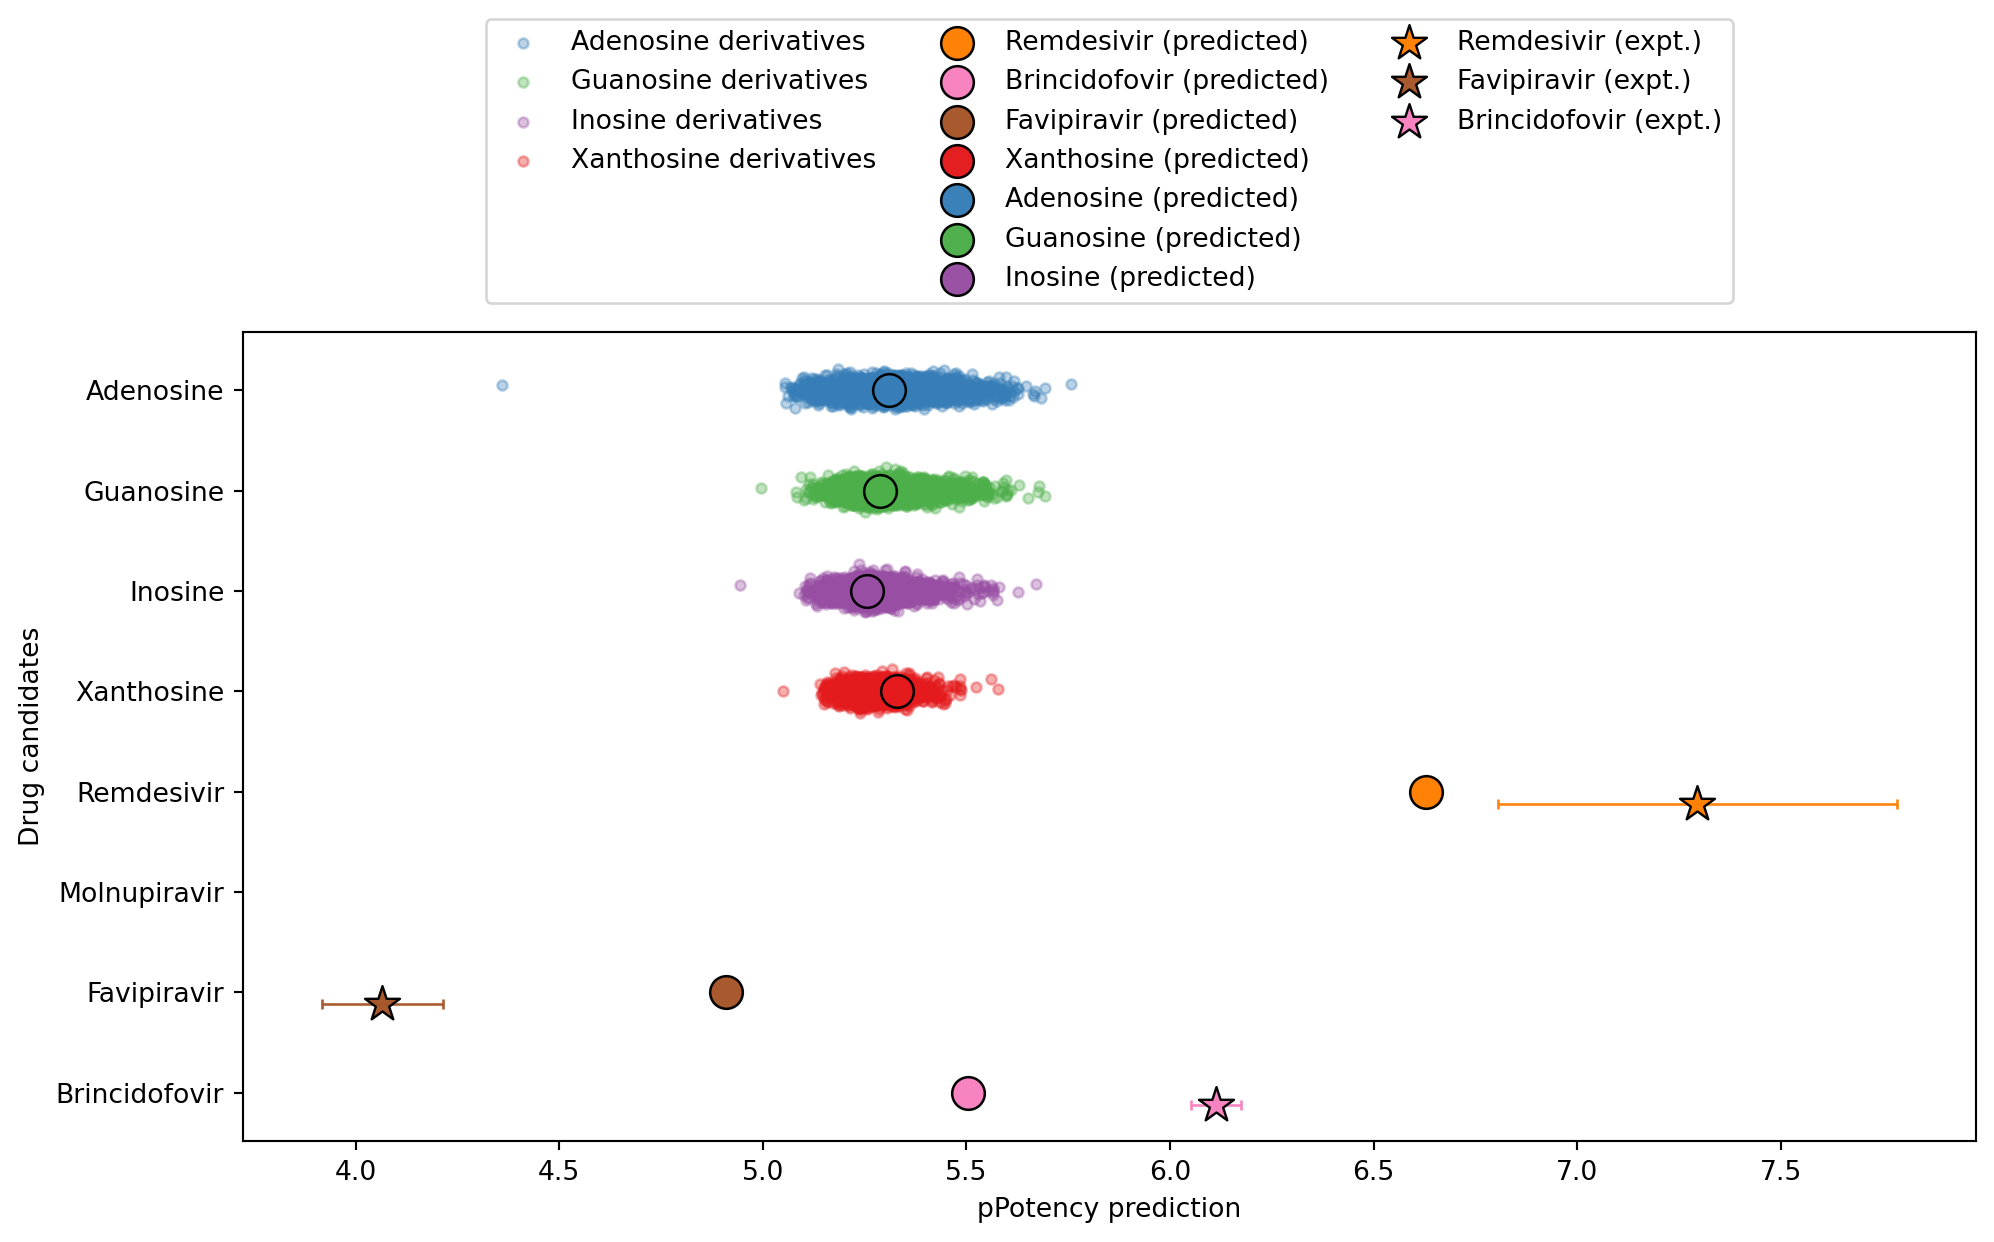

In [64]:
ypos={n:i for i,n in enumerate(candidateOrder)}; rng=np.random.default_rng(123)
fig,ax=plt.subplots(figsize=(10.5,7.5))
for srcName,srcDF in scoredCandMap.items():
    if srcName=="Individual": continue
    pDf=srcDF.dropna(subset=["pPotency_prediction"]).copy()
    bN=sourceToBase.get(srcName); y0=ypos.get(bN)
    if y0 is None: continue
    yj=y0+rng.normal(0,0.06,len(pDf))
    ax.scatter(pDf["pPotency_prediction"],yj,s=14,alpha=0.35,
               color=baseColorMap.get(bN,"gray"),label=f"{bN} derivatives")
if "Individual" in scoredCandMap:
    iDF=(scoredCandMap["Individual"].dropna(subset=["drugName","pPotency_prediction"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())
    for _,row in iDF.iterrows():
        dname=row["drugName"]
        if dname not in ypos: continue
        ax.scatter(row["pPotency_prediction"],ypos[dname],marker="o",s=150,
                   color=baseColorMap.get(dname,"black"),edgecolors="black",
                   linewidths=0.95,alpha=0.98,label=f"{dname} (predicted)",zorder=6)
eDf=(exptScoreDF.dropna(subset=["drugName","pPotency_prediction"]).drop_duplicates(subset=["drugName","SMILES"]).copy())
for _,row in eDf.iterrows():
    dname=row["drugName"]
    if dname not in ypos: continue
    yy=ypos[dname]+0.12; c=baseColorMap.get(dname,"black")
    ax.scatter(row["pPotency_prediction"],yy,marker="*",s=190,color=c,edgecolors="black",
               linewidths=0.9,alpha=0.98,label=f"{dname} (expt.)",zorder=7)
    if pd.notna(row.get("pPotency_std",np.nan)):
        ax.errorbar(row["pPotency_prediction"],yy,xerr=float(row["pPotency_std"]),
                    fmt="none",ecolor=c,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Drug candidates")
ax.set_yticks(range(len(candidateOrder))); ax.set_yticklabels(candidateOrder)
ax.invert_yaxis(); ax.yaxis.grid(False)
hh,ll=orderedLegend(ax)
ax.legend(hh,ll,loc="lower center",bbox_to_anchor=(0.5,1.02),ncol=3,frameon=True,prop=tnr)
plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotencyOnly.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotencyOnly.png"),format="png",dpi=600)
plt.show()

### Plot 2: pPotency vs. core toxicity

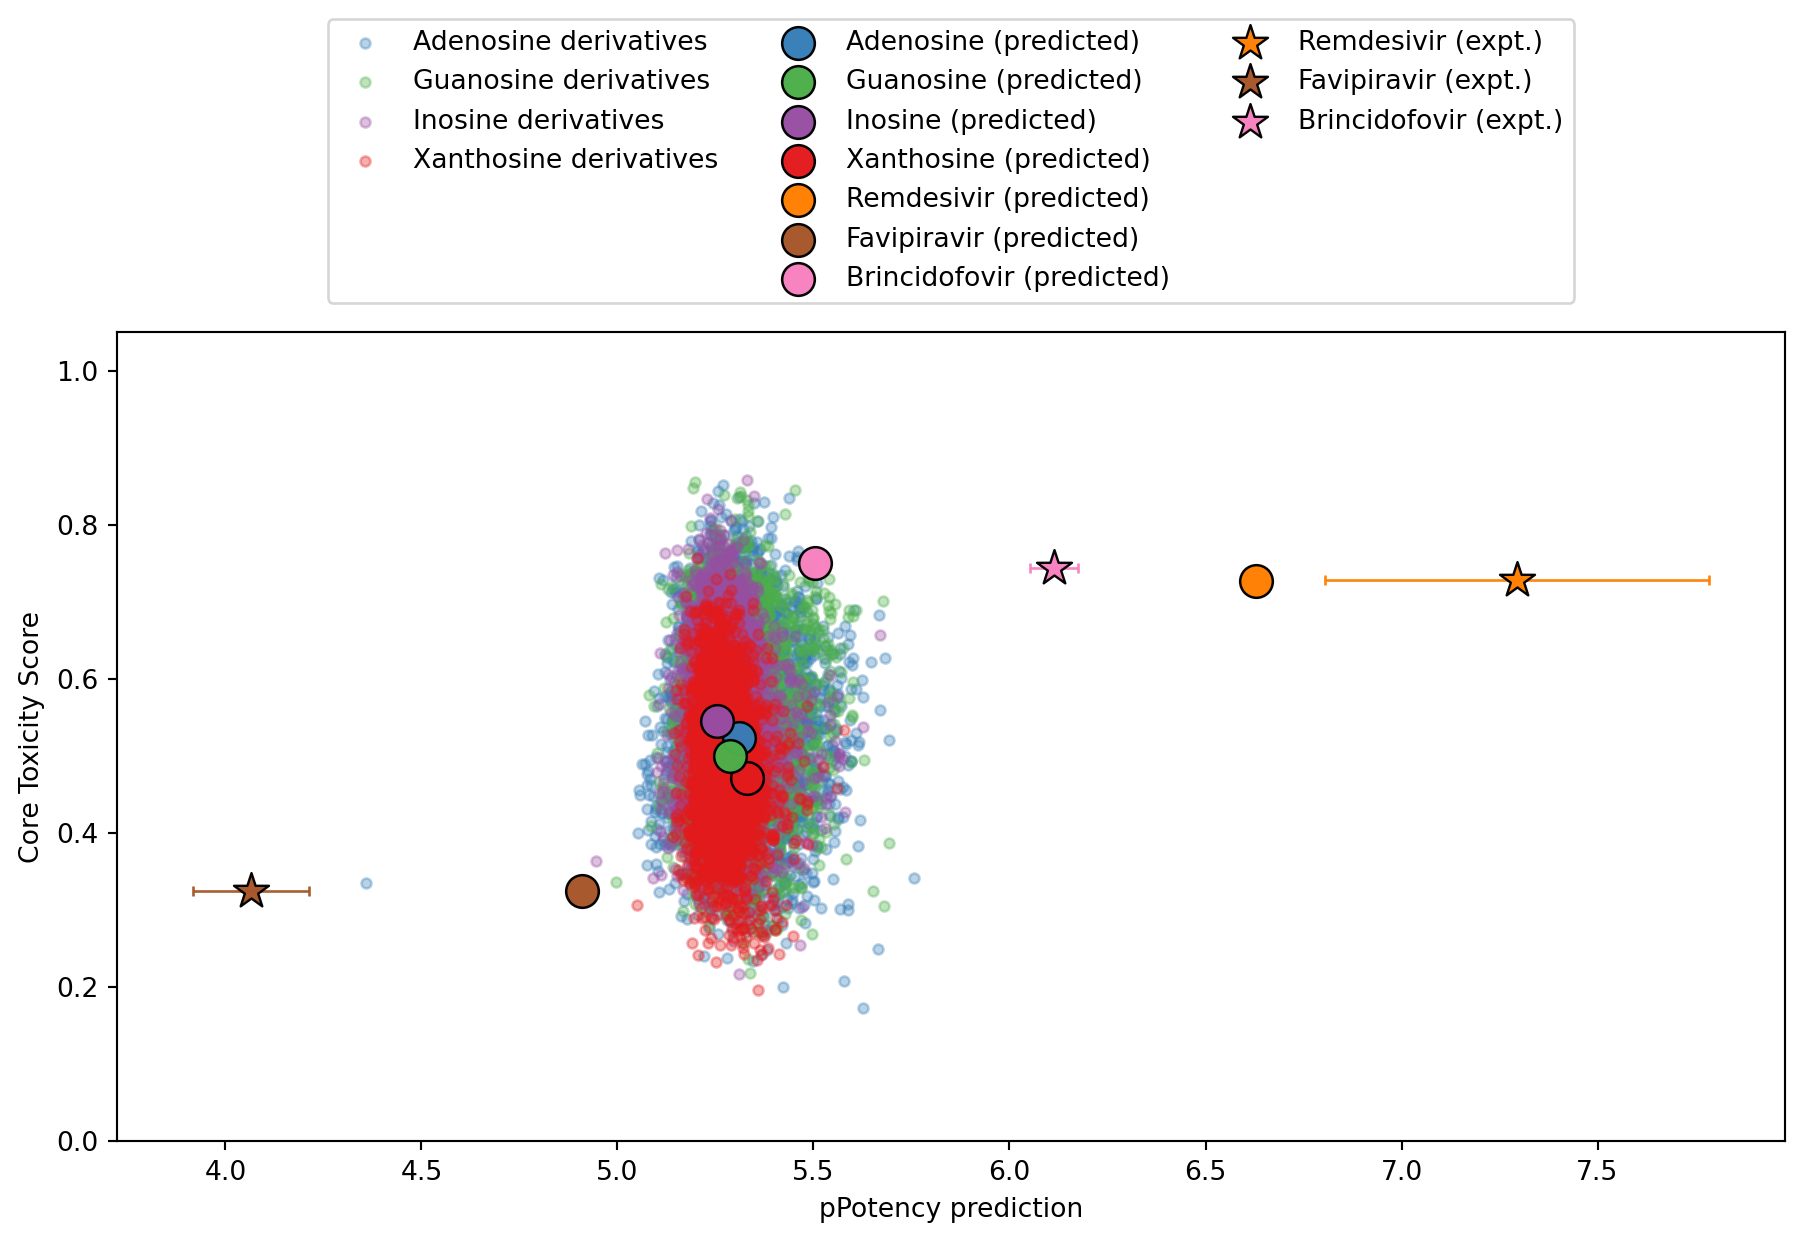

In [67]:
fig,ax=plt.subplots(figsize=(9.5,7.5))
for srcName,srcDF in scoredCandMap.items():
    if srcName=="Individual": continue
    pDf=srcDF.dropna(subset=["pPotency_prediction","coreToxicityScore"]).copy()
    bN=sourceToBase.get(srcName)
    ax.scatter(pDf["pPotency_prediction"],pDf["coreToxicityScore"],s=14,alpha=0.35,
               color=baseColorMap.get(bN,"gray"),label=f"{bN} derivatives")
if "Individual" in scoredCandMap:
    iDF=(scoredCandMap["Individual"].dropna(subset=["drugName","pPotency_prediction","coreToxicityScore"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())
    for _,row in iDF.iterrows():
        dname=row["drugName"]
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="o",s=150,
                   color=baseColorMap.get(dname,"black"),edgecolors="black",
                   linewidths=0.95,alpha=0.98,label=f"{dname} (predicted)",zorder=6)
for _,row in (exptScoreDF.dropna(subset=["drugName","pPotency_prediction","coreToxicityScore"])
              .drop_duplicates(subset=["drugName","SMILES"]).iterrows()):
    dname=row["drugName"]; c=baseColorMap.get(dname,"black")
    ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="*",s=190,color=c,
               edgecolors="black",linewidths=0.9,alpha=0.98,label=f"{dname} (expt.)",zorder=7)
    if pd.notna(row.get("pPotency_std",np.nan)):
        ax.errorbar(row["pPotency_prediction"],row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]),fmt="none",ecolor=c,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Core Toxicity Score")
ax.set_ylim(0,1.05); ax.grid(False)

# Build legend in explicit column order: derivatives | predicted | expt.
# candidateOrder drives within-column ordering so the layout matches the target figure.
allHandles, allLabels = ax.get_legend_handles_labels()
labelToHandle = dict(zip(allLabels, allHandles))
blank = Patch(color="none", label="")

derivLabels = [f"{n} derivatives" for n in candidateOrder if f"{n} derivatives" in labelToHandle]
predLabels  = [f"{n} (predicted)" for n in candidateOrder if f"{n} (predicted)" in labelToHandle]
exptLabels  = [f"{n} (expt.)"     for n in candidateOrder if f"{n} (expt.)"     in labelToHandle]

nRows = max(len(derivLabels), len(predLabels), len(exptLabels))
def padCol(lst): return lst + [""] * (nRows - len(lst))

orderedLabels  = padCol(derivLabels) + padCol(predLabels) + padCol(exptLabels)
orderedHandles = [labelToHandle.get(l, blank) for l in orderedLabels]

ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5,1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity.png"),format="png",dpi=600)
plt.show()

### Plot 3: pPotency vs. core toxicity with ADME bubble size

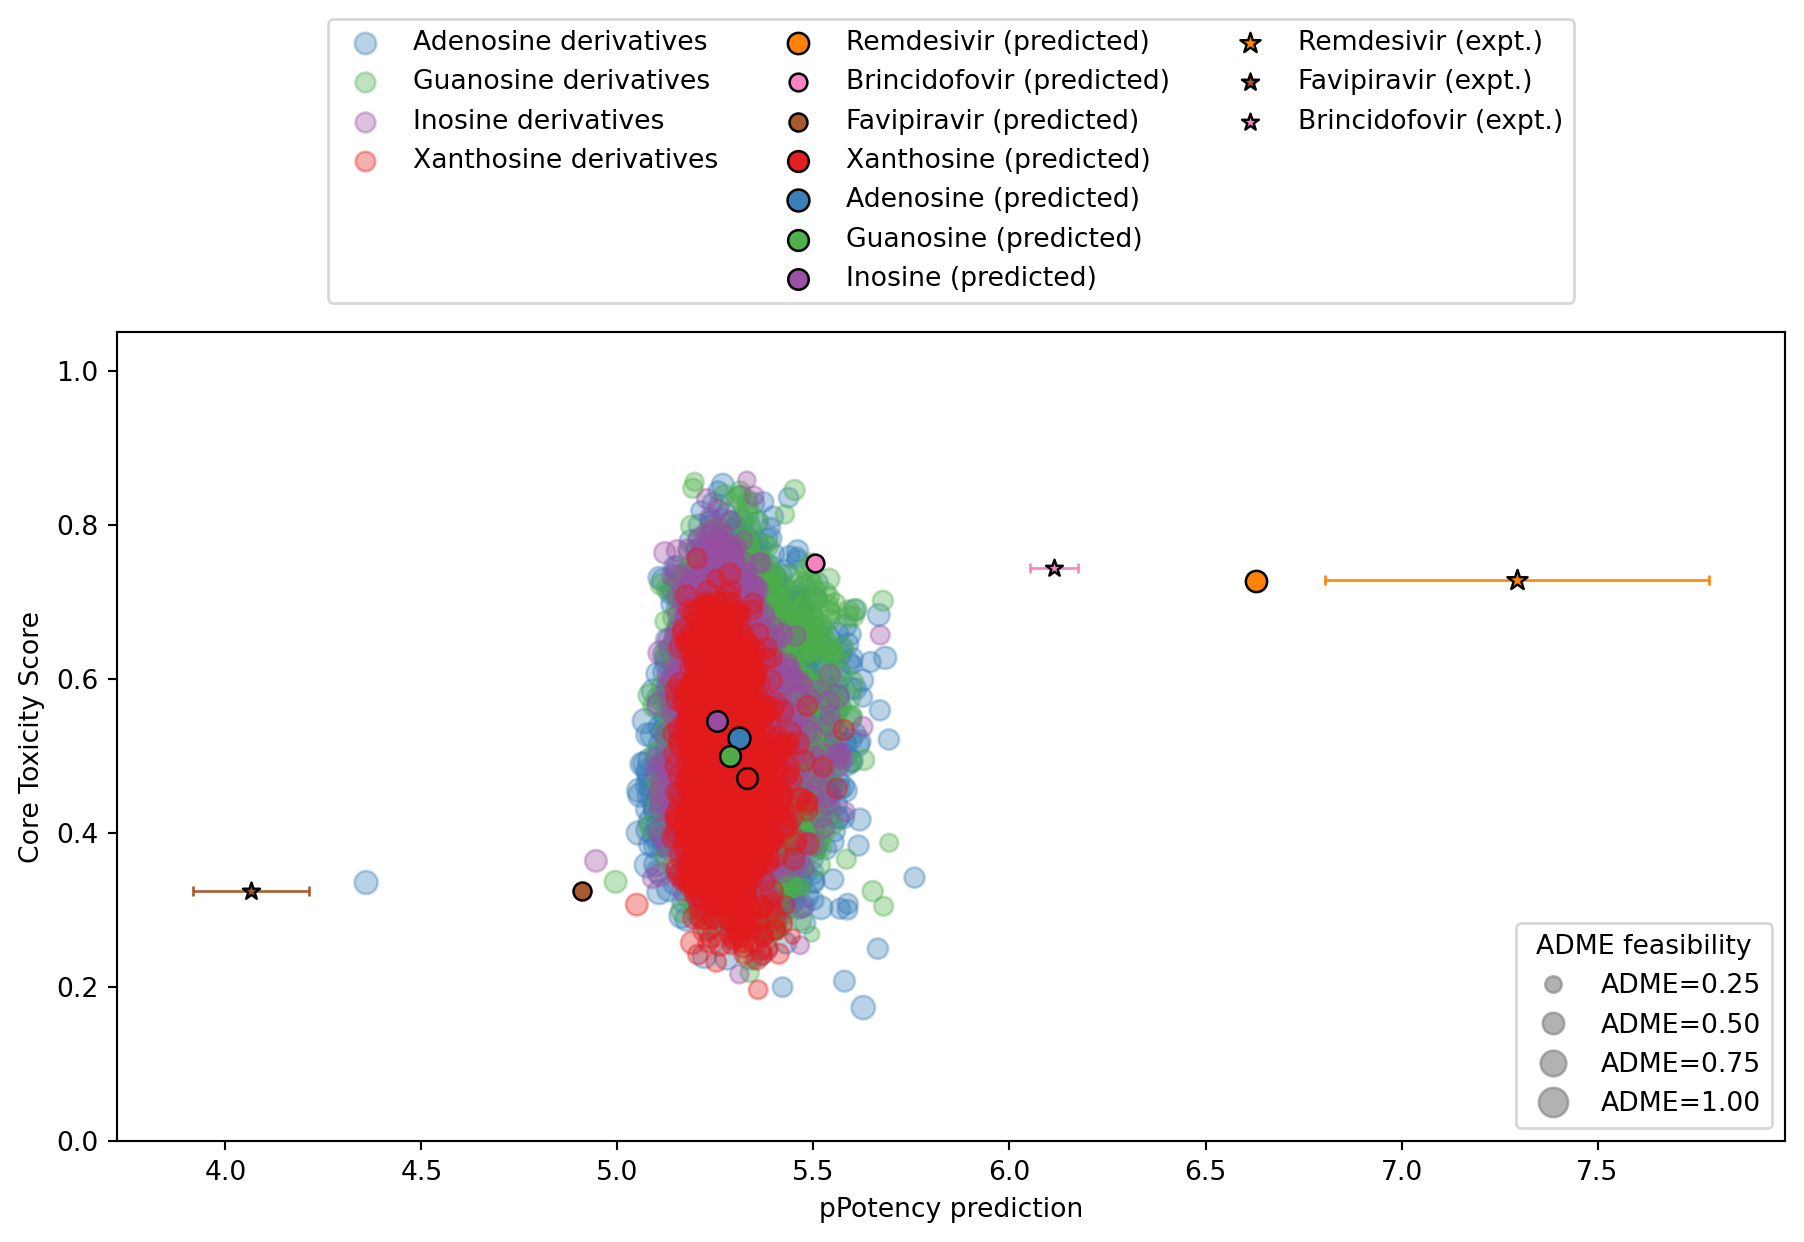

In [68]:
fig,ax=plt.subplots(figsize=(9.5,7.5))
for srcName,srcDF in scoredCandMap.items():
    if srcName=="Individual": continue
    pDf=srcDF.dropna(subset=["pPotency_prediction","coreToxicityScore","ADMEfeasibility"]).copy()
    bN=sourceToBase.get(srcName)
    ax.scatter(pDf["pPotency_prediction"],pDf["coreToxicityScore"],
               s=admeToSize(pDf["ADMEfeasibility"].values),alpha=0.35,
               color=baseColorMap.get(bN,"gray"),label=f"{bN} derivatives")
if "Individual" in scoredCandMap:
    iDF=(scoredCandMap["Individual"].dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())
    for _,row in iDF.iterrows():
        dname=row["drugName"]
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="o",
                   s=admeToSize(float(row["ADMEfeasibility"])),
                   color=baseColorMap.get(dname,"black"),edgecolors="black",
                   linewidths=0.95,alpha=0.98,label=f"{dname} (predicted)",zorder=6)
for _,row in (exptScoreDF.dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
              .drop_duplicates(subset=["drugName","SMILES"]).iterrows()):
    dname=row["drugName"]; c=baseColorMap.get(dname,"black")
    ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],marker="*",
               s=admeToSize(float(row["ADMEfeasibility"])),color=c,edgecolors="black",
               linewidths=0.9,alpha=0.98,label=f"{dname} (expt.)",zorder=7)
    if pd.notna(row.get("pPotency_std",np.nan)):
        ax.errorbar(row["pPotency_prediction"],row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]),fmt="none",ecolor=c,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
admeLeg=ax.legend(handles=[mlines.Line2D([],[],linestyle="none",marker="o",color="gray",alpha=0.6,
    markersize=np.sqrt(admeToSize(v)),label=f"ADME={v:.2f}") for v in [0.25,0.50,0.75,1.00]],
    title="ADME feasibility",loc="lower right",frameon=True,prop=tnr,title_fontproperties=tnr)
ax.add_artist(admeLeg)
ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Core Toxicity Score")
ax.set_ylim(0,1.05); ax.grid(False)
hh,ll=orderedLegend(ax)
ax.legend(hh,ll,loc="lower center",bbox_to_anchor=(0.5,1.02),ncol=3,frameon=True,prop=tnr)
plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME.png"),format="png",dpi=600)
plt.show()

### Plot 4: per-starter subplot grid with ADME marker shapes

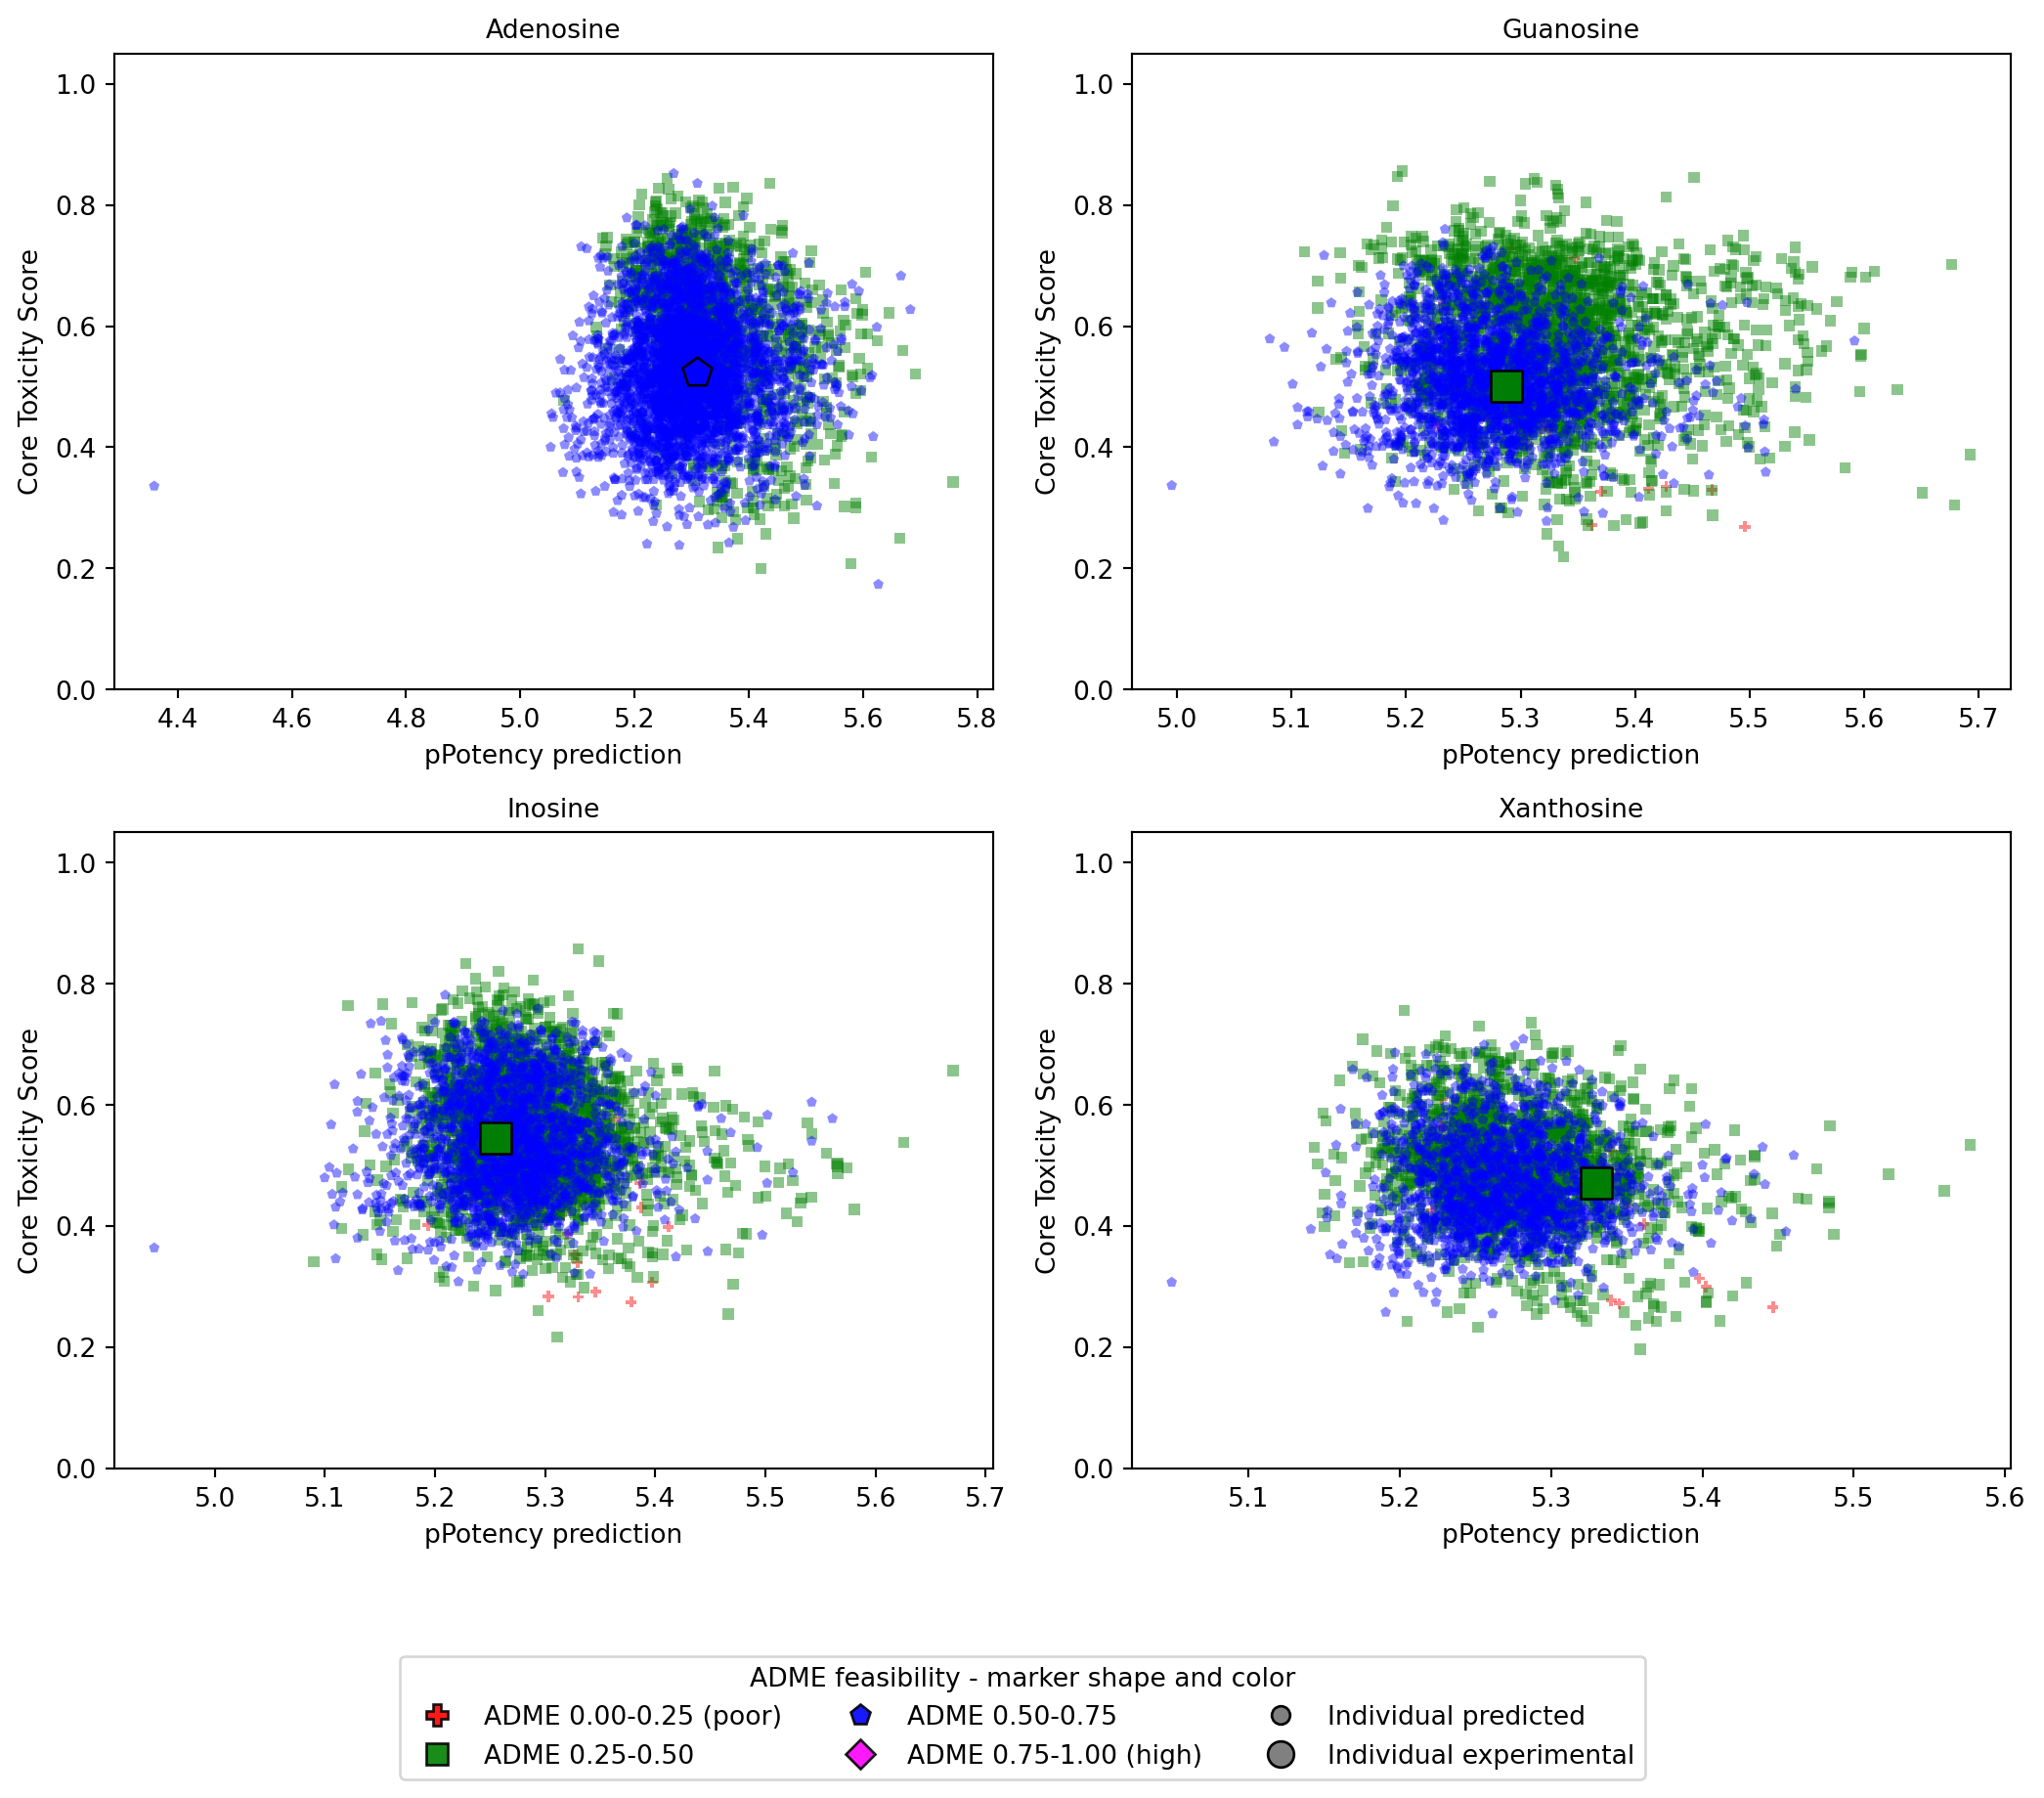

In [69]:
admeBinsDef=[(0.00,0.25,"P","red","ADME 0.00-0.25 (poor)"),
               (0.25,0.50,"s","green","ADME 0.25-0.50"),
               (0.50,0.75,"p","blue","ADME 0.50-0.75"),
               (0.75,1.00,"D","magenta","ADME 0.75-1.00 (high)")]

def getAdmeBin(v):
    for lo,hi,mk,col,_ in admeBinsDef:
        if lo<=float(v)<=hi: return mk,col
    return "P","red"

familyPlotOrder=[s for s in sourceToBase.keys() if s in scoredCandMap]
nF=len(familyPlotOrder); nC=2; nR=-(-nF//nC)

indivAll=pd.DataFrame()
if "Individual" in scoredCandMap:
    indivAll=(scoredCandMap["Individual"]
              .dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
              .drop_duplicates(subset=["drugName","SMILES"]).copy())
exptAll=(exptScoreDF.dropna(subset=["drugName","pPotency_prediction","coreToxicityScore","ADMEfeasibility"])
         .drop_duplicates(subset=["drugName","SMILES"]).copy())

fig,axes=plt.subplots(nR,nC,figsize=(11,nR*4.8))
axes=axes.flatten() if nR*nC>1 else [axes]

for i,srcName in enumerate(familyPlotOrder):
    ax=axes[i]; bN=sourceToBase[srcName]
    pDf=scoredCandMap[srcName].dropna(subset=["pPotency_prediction","coreToxicityScore","ADMEfeasibility"]).copy()
    for lo,hi,mk,col,_ in admeBinsDef:
        mask=(pDf["ADMEfeasibility"]>=lo)&(pDf["ADMEfeasibility"]<=hi)
        if mask.any(): ax.scatter(pDf.loc[mask,"pPotency_prediction"],pDf.loc[mask,"coreToxicityScore"],
                                   s=18,marker=mk,alpha=0.45,color=col,edgecolors="none")
    for _,row in indivAll[indivAll["drugName"]==bN].iterrows():
        mk,col=getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],
                   marker=mk,s=140,color=col,edgecolors="black",linewidths=0.95,alpha=0.98,zorder=6)
    for _,row in exptAll[exptAll["drugName"]==bN].iterrows():
        mk,col=getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(row["pPotency_prediction"],row["coreToxicityScore"],
                   marker=mk,s=220,color=col,edgecolors="black",linewidths=1.1,alpha=0.98,zorder=7)
        if pd.notna(row.get("pPotency_std",np.nan)):
            ax.errorbar(row["pPotency_prediction"],row["coreToxicityScore"],
                        xerr=float(row["pPotency_std"]),fmt="none",ecolor=col,elinewidth=1.0,capsize=2,alpha=0.95,zorder=6)
    ax.set_title(bN); ax.set_xlabel("pPotency prediction"); ax.set_ylabel("Core Toxicity Score")
    ax.set_ylim(0,1.05)

for j in range(nF,len(axes)): axes[j].set_visible(False)

fig.legend(handles=[
    mlines.Line2D([],[],linestyle="none",marker=mk,color=col,markersize=8,
                  markeredgecolor="black",alpha=0.9,label=lbl)
    for _,_,mk,col,lbl in admeBinsDef]+[
    mlines.Line2D([],[],linestyle="none",marker="o",color="gray",markersize=7,markeredgecolor="black",label="Individual predicted"),
    mlines.Line2D([],[],linestyle="none",marker="o",color="gray",markersize=10,markeredgecolor="black",label="Individual experimental"),
],loc="lower center",bbox_to_anchor=(0.5,0.0),ncol=3,frameon=True,prop=tnr,
  title="ADME feasibility - marker shape and color",title_fontproperties=tnr)
plt.tight_layout(rect=[0,0.12,1,1])
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME_perStarter.svg"),format="svg",dpi=600)
plt.savefig(os.path.join(resultsDir,f"{target}_pPotency_CoreToxicity_ADME_perStarter.png"),format="png",dpi=600)
plt.show()

# List Antivirals compounds for `Deep Origin` ADMET screening

In [53]:
Antiviral_DORAnet_Library = pd.read_csv(resultsDir + "/Ebola_Generated_Compounds_wART.csv")
Antiviral_FDA_Library = pd.read_csv(resultsDir + "/fdaAntiviralDF_wART.csv")

lib1 = Antiviral_DORAnet_Library[["Canonical_SMILES", "Starter_Name"]].copy()
lib2 = (Antiviral_FDA_Library[["Canonical_SMILES", "Drug_Type"]]
        .rename(columns={"Drug_Type": "Starter_Name"})
        .copy())

# merge both libraries
masterDF = pd.concat([lib1, lib2], ignore_index=True)
masterDF = masterDF[["Starter_Name", "Canonical_SMILES"]]

print(f"Antiviral_DORAnet_Library compounds: {len(lib1):,}")
print(f"Antiviral_FDA_Library compounds: {len(lib2):,}")
print(f"Combined rows: {len(masterDF):,}")
print(f"Unique Starter_Name values ({masterDF['Starter_Name'].nunique()}): {sorted(masterDF['Starter_Name'].dropna().unique())}")

masterPath = os.path.join(resultsDir, "Antivirals_DeepOrigin.csv")
masterDF.to_csv(masterPath, index=False)
print("Saved:", masterPath)
masterDF.head(10)

Antiviral_DORAnet_Library compounds: 19,016
Antiviral_FDA_Library compounds: 76
Combined rows: 19,092
Unique Starter_Name values (7): ['Adenosine', 'Brincidofovir', 'Guanosine', 'Inosine', 'Remdesivir', 'Xanthosine', 'antiviral']
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Antivirals_DeepOrigin.csv


,Starter_Name,Canonical_SMILES
0,Remdesivir,CCC(CC)CC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)OP(=...
1,Adenosine,CC(=O)OP(=O)(O)OC(C)=O
2,Remdesivir,O=C(O)c1ccccc1
3,Remdesivir,Oc1ccccc1
4,Remdesivir,CC(C)=CCc1ccccc1O
5,Remdesivir,CCN[P@@](=O)(Oc1cccc(C(=O)OCC(CC)CC)c1)OP(=O)(O)O
6,Remdesivir,CCC(CC)COC(=O)O[C@H](C)N[P@@](=O)(Oc1ccccc1)OP...
7,Remdesivir,Oc1cccc(O)c1
8,Remdesivir,CCC(C)(C)COC(=O)[C@H](C)N[P@@](=O)(Oc1ccccc1)O...
9,Remdesivir,Oc1ccccc1O
